# IMPORTS

In [1]:
import ast
import argparse
import os
from pathlib import Path

import h5py
import matplotlib  # noqa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf  # noqa

# matplotlib.use("module://ipykernel.pylab.backend_inline")

2026-02-13 09:24:03.781509: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-13 09:24:03.781577: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-13 09:24:03.781619: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-13 09:24:03.790845: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
%load_ext autoreload
%autoreload 2


_pwd = Path(os.getcwd())
os.chdir(_pwd / "phasenet")  # Use this line to load modules correctly

from phasenet.data_reader import DataReader_pred, DataReader_train, DataReader_test  # (do not use), DataReader  # noqa: E402 F401
from phasenet.visulization import plot_waveform  # noqa: E402
from phasenet.postprocess import (  # noqa: E402 F401
    extract_picks,
    save_picks,
    convert_true_picks,
    calc_performance,
)
from phasenet.postanalysis import (  # noqa: E402
    load_config,
    extract_losses,
    plot_losses,
    find_matches,
    match_picks,  # previously `classify_matches`
    calc_phase_metrics,
    # count_picks,  # GONE
    aggregate_picks,
    analyze_results,
    group_results,
)
# GONE: count_picks, calc_confidence_matrix, calc_metrics_cm


os.chdir(_pwd)  # Return to the previous path

# HELPERS

In [ ]:
# def load_config(path: Path|str) -> dict:
#     config = {}
#     with open(path, "r") as f:
#         for line in f:
#             line = line.strip()
#             if not line or line.startswith("#"):
#                 continue
#             key, value = line.split(":", 1)
#             key = key.strip()
#             value = value.strip()
#             # Try to interpret lists/numbers; fall back to raw string
#             try:
#                 config[key] = ast.literal_eval(value)
#             except (SyntaxError, ValueError):
#                 config[key] = value
#     return config


# def extract_losses(loss_log: Path|str) -> dict[str: list[float]]:
#     with open(loss_log, "r") as file:
#         lines = file.readlines()

#     losses = {"train": [], "valid": []}
#     for line in lines:
#         if line.lower().startswith("epoch"):
#             losses["train"].append(float(line.split(": ")[-1]))
#         elif line.lower().startswith("valid"):
#             losses["valid"].append(float(line.split(": ")[-1]))
#         elif len(line)>0:
#             print(f"Unknown line: {line}")
#     return losses


# def plot_losses(model_loss_log_path: Path|str, ax:plt.Axes=None, ls=None) -> plt.Figure:

#     model_station = model_loss_log_path.parent.name.split("_")[0]
#     model_losses = extract_losses(model_loss_log_path)

#     if ax is None:
#         fig, ax = plt.subplots(figsize=(8,4))
#     ax.plot(model_losses["train"], label=f"Train ({np.argmin(model_losses['train'])})", ls=ls)
#     ax.plot(np.argmin(model_losses["train"]), min(model_losses["train"]), "o", color=ax.get_lines()[-1].get_color())
#     ax.plot(model_losses["valid"], label=f"Valid ({np.argmin(model_losses['valid'])})", ls=ls)
#     ax.plot(np.argmin(model_losses["valid"]), min(model_losses["valid"]), "o", color=ax.get_lines()[-1].get_color())
#     ax.set_xlabel("Epoch")
#     ax.set_ylabel("Loss")
#     ax.set_yscale("log")
#     ax.set_title(f"{model_station}")
#     ax.legend()

#     return ax.get_figure()




In [4]:
# def plot_waveform(data, pred, fname, label=None, 
#                   itp=None, its=None, itps=None,
#                   itp_pred=None, its_pred=None, itps_pred=None,
#                   figure_dir="./", dt=0.01):

#     t = np.arange(0, pred.shape[0]) * dt
#     box = dict(boxstyle='round', facecolor='white', alpha=1)
#     text_loc = [0.05, 0.77]

#     plt.figure()
    
#     plt.subplot(411)
#     plt.plot(t, data[:, 0, 0], 'k', label='E', linewidth=0.5)
#     plt.autoscale(enable=True, axis='x', tight=True)
#     tmp_min = np.min(data[:, 0, 0])
#     tmp_max = np.max(data[:, 0, 0])
#     if (itp is not None) and (its is not None):
#         for j in range(len(itp)):
#             lb = "P" if j==0 else ""
#             plt.plot([itp[j]*dt, itp[j]*dt], [tmp_min, tmp_max], 'C0', label=lb, linewidth=0.5)
#         for j in range(len(its[i])):
#             lb = "S" if j==0 else ""
#             plt.plot([its[j]*dt, its[j]*dt], [tmp_min, tmp_max], 'C1', label=lb, linewidth=0.5)
#     if (itps is not None):
#         for j in range(len(itps)):
#             lb = "PS" if j==0 else ""
#             plt.plot([itps[j]*dt, its[j]*dt], [tmp_min, tmp_max], 'C2', label=lb, linewidth=0.5)
#     plt.ylabel('Amplitude')
#     plt.legend(loc='upper right', fontsize='small')
#     plt.gca().set_xticklabels([])
#     plt.text(text_loc[0], text_loc[1], '(i)', horizontalalignment='center',
#                 transform=plt.gca().transAxes, fontsize="small", fontweight="normal", bbox=box)
    
#     plt.subplot(412)
#     plt.plot(t, data[:, 0, 1], 'k', label='N', linewidth=0.5)
#     plt.autoscale(enable=True, axis='x', tight=True)
#     tmp_min = np.min(data[:, 0, 1])
#     tmp_max = np.max(data[:, 0, 1])
#     if (itp is not None) and (its is not None):
#         for j in range(len(itp)):
#             lb = "P" if j==0 else ""
#             plt.plot([itp[j]*dt, itp[j]*dt], [tmp_min, tmp_max], 'C0', label=lb, linewidth=0.5)
#         for j in range(len(its)):
#             lb = "S" if j==0 else ""
#             plt.plot([its[j]*dt, its[j]*dt], [tmp_min, tmp_max], 'C1', label=lb, linewidth=0.5)
#     if (itps is not None):
#         for j in range(len(itps)):
#             lb = "PS" if j==0 else ""
#             plt.plot([itps[j]*dt, itps[j]*dt], [tmp_min, tmp_max], 'C2', label=lb, linewidth=0.5)
#     plt.ylabel('Amplitude')
#     plt.legend(loc='upper right', fontsize='small')
#     plt.gca().set_xticklabels([])
#     plt.text(text_loc[0], text_loc[1], '(ii)', horizontalalignment='center',
#             transform=plt.gca().transAxes, fontsize="small", fontweight="normal", bbox=box)
    
#     plt.subplot(413)
#     plt.plot(t, data[:, 0, 2], 'k', label='Z', linewidth=0.5)
#     plt.autoscale(enable=True, axis='x', tight=True)
#     tmp_min = np.min(data[:, 0, 2])
#     tmp_max = np.max(data[:, 0, 2])
#     if (itp is not None) and (its is not None):
#         for j in range(len(itp)):
#             lb = "P" if j==0 else ""
#             plt.plot([itp[j]*dt, itp[j]*dt], [tmp_min, tmp_max], 'C0', label=lb, linewidth=0.5)
#         for j in range(len(its)):
#             lb = "S" if j==0 else ""
#             plt.plot([its[j]*dt, its[j]*dt], [tmp_min, tmp_max], 'C1', label=lb, linewidth=0.5)
#     if (itps is not None):
#         for j in range(len(itps)):
#             lb = "PS" if j==0 else ""
#             plt.plot([itps[j]*dt, itps[j]*dt], [tmp_min, tmp_max], 'C2', label=lb, linewidth=0.5)
#     plt.ylabel('Amplitude')
#     plt.legend(loc='upper right', fontsize='small')
#     plt.gca().set_xticklabels([])
#     plt.text(text_loc[0], text_loc[1], '(iii)', horizontalalignment='center',
#             transform=plt.gca().transAxes, fontsize="small", fontweight="normal", bbox=box)
    
#     plt.subplot(414)
#     if label is not None:
#         plt.plot(t, label[:, 0, 1], 'C0', label='P', linewidth=1)
#         plt.plot(t, label[:, 0, 2], 'C1', label='S', linewidth=1)
#         if label.shape[-1] == 4:
#             plt.plot(t, label[:, 0, 3], 'C2', label='PS', linewidth=1)
#     plt.plot(t, pred[:, 0, 1], '--C0', label='$\hat{P}$', linewidth=1)
#     plt.plot(t, pred[:, 0, 2], '--C1', label='$\hat{S}$', linewidth=1)
#     if pred.shape[-1] == 4:
#         plt.plot(t, pred[:, 0, 3], '--C2', label='$\hat{PS}$', linewidth=1)
#     plt.autoscale(enable=True, axis='x', tight=True)
#     if (itp_pred is not None) and (its_pred is not None) :
#         for j in range(len(itp_pred)):
#             plt.plot([itp_pred[j]*dt, itp_pred[j]*dt], [-0.1, 1.1], '--C0', linewidth=1)
#         for j in range(len(its_pred)):
#             plt.plot([its_pred[j]*dt, its_pred[j]*dt], [-0.1, 1.1], '--C1', linewidth=1)
#     if (itps_pred is not None):
#         for j in range(len(itps_pred)):
#             plt.plot([itps_pred[j]*dt, itps_pred[j]*dt], [-0.1, 1.1], '--C2', linewidth=1)
#     plt.ylim([-0.05, 1.05])
#     plt.text(text_loc[0], text_loc[1], '(iv)', horizontalalignment='center',
#                 transform=plt.gca().transAxes, fontsize="small", fontweight="normal", bbox=box)
#     plt.legend(loc='upper right', fontsize='small', ncol=2)
#     plt.xlabel('Time (s)')
#     plt.ylabel('Probability')
#     plt.tight_layout()
#     plt.gcf().align_labels()

#     if figure_dir:
#         try:
#             plt.savefig(os.path.join(figure_dir, fname+'.png'), bbox_inches='tight')
#         except FileNotFoundError:
#             os.makedirs(os.path.dirname(os.path.join(figure_dir, fname)), exist_ok=True)
#             plt.savefig(os.path.join(figure_dir, fname+'.png'), bbox_inches='tight')

#     # plt.close()
#     return plt.gcf().figure

In [ ]:
# def find_matches(idx_true:list, idx_pred:list, tolerance:float|int, unique:bool=False) -> list[tuple[int, int]]:
#     """Find matches between two list of numbers within a tolerance window
#     """

#     def remove_duplicates(matches:list[tuple]) -> list[tuple]:
#         """Remove tuples with duplicated indices
#         """
#         matches_ = [(i, a, b, abs(a - b)) for i, (a, b) in enumerate(matches)]
#         matches_.sort(key=lambda x: x[-1])
#         chosen_idxs, v1_used, v2_used = [], set(), set()
#         for i, v1, v2, gap in matches_:
#             if v1 in v1_used or v2 in v2_used:
#                 continue
#             chosen_idxs.append(i)
#             v1_used.add(v1), v2_used.add(v2)
#         unique_matches = [matches[i] for i in sorted(chosen_idxs)]
#         return unique_matches

#     m_true = np.array(idx_true).reshape((-1, 1)).repeat(len(idx_pred), axis=1)
#     m_pred = np.array(idx_pred).reshape((1, -1)).repeat(len(idx_true), axis=0)
#     m = m_true - m_pred
#     idx_matches = np.argwhere(np.abs(m) <= tolerance)
#     matches = [(idx_true[i], idx_pred[j]) for i,j in idx_matches]
#     if unique:
#         matches = remove_duplicates(matches)

#     return matches


# def classify_matches(name:str, itp:list[int], its:list[int], itp_pred:list[int], its_pred:list[int], tolerance:float, dt:float=0.01, unique:bool=False):

#     # Confusion matrix: classify matching event-pick pairs
#     PasP = find_matches(itp, itp_pred, tolerance/dt, unique)
#     SasS = find_matches(its, its_pred, tolerance/dt, unique)

#     # Information needed for phase metrics
#     P_true = [_[1] for _ in PasP]  # Similar to PasP
#     S_true = [_[1] for _ in SasS]  # SasS
#     P_false = list(set(itp_pred) - set(P_true))  # SasP and NasP
#     S_false = list(set(its_pred) - set(S_true))  # PasS and NasS
#     P_miss = list(set(itp) - set([_[0] for _ in PasP]))  # PasS and PasN
#     S_miss = list(set(its) - set([_[0] for _ in SasS]))  # SasP and SasN

#     # Extra data to know the type of wrong detection (do not use for CM)
#     # wrong_itp_pred = list(set(itp_pred) - set([_[1] for _ in PasP]))
#     # wrong_its_pred = list(set(its_pred) - set([_[1] for _ in SasS]))
#     # SasP = find_matches(its, wrong_itp_pred, tolerance/dt, unique)
#     # PasS = find_matches(itp, wrong_its_pred, tolerance/dt, unique)
#     SasP = find_matches(its, P_false, tolerance/dt, unique)
#     PasS = find_matches(itp, S_false, tolerance/dt, unique)
#     NasP = list(set(itp_pred) - set(_[1] for _ in PasP) - set(_[1] for _ in SasP))  # event index
#     NasS = list(set(its_pred) - set(_[1] for _ in SasS) - set(_[1] for _ in PasS))  # event index
#     PasN = list(set(itp) - set(_[0] for _ in PasP) - set(_[0] for _ in PasS))  # event index
#     SasN = list(set(its) - set(_[0] for _ in SasS) - set(_[0] for _ in SasP))  # event index
#     # NasN = []

#     matched_picks = {
#         "P_true": P_true, "P_false": P_false, "P_miss": P_miss,
#         "S_true": S_true, "S_false": S_false, "S_miss": S_miss,
#         # "PasP": [_[1] for _ in PasP], "SasP": [_[1] for _ in SasP], "NasP": NasP,
#         # "PasS": [_[1] for _ in PasS], "SasS": [_[1] for _ in SasS], "NasS": NasS,
#         "PasP": PasP, "SasP": SasP, "NasP": NasP,
#         "PasS": PasS, "SasS": SasS, "NasS": NasS,
#         "PasN": PasN, "SasN": SasN, "NasN": np.NAN,
#     }

#     return pd.Series(matched_picks, name=name)


# def count_picks(df_matches: pd.DataFrame) -> pd.DataFrame:
#     cm_elems = ["PasP", "SasP", "NasP", "PasS", "SasS", "NasS", "PasN", "SasN", "NasN"]
#     return df_matches[cm_elems].apply(lambda r: [len(v) for k, v in r.items()], axis=0)


# def calc_confidence_matrix(df_matches: pd.DataFrame) -> np.ndarray:
#     cm = count_picks(df_matches).sum()
#     # cm = df_matches[cm_elems].apply(lambda r: [len(v) for k, v in r.items()], axis=0).sum()
#     cm = cm.to_numpy().reshape((3,3))
#     return cm


# def calc_metrics_cm(df_matches: pd.DataFrame) -> tuple[dict, np.ndarray]:
#     """Calculate precision, recall and F1-score of two lists of indices

#     NOTE:
#     - Recall can be greater than 1 if more than one detection within the tolerance window (if unique=False).
#     - Precision is lower with unique=True if an event is detected several times.
#     - Pick can be counted twice in the CM matrix, since S and P events are independent.
#     """
#     cm = calc_confidence_matrix(df_matches)
#     p_events, s_events, false_alarms = cm.sum(axis=0)
#     p_picks, s_picks, undetected = cm.sum(axis=1)
#     p_pr = cm[0,0] / p_picks if p_picks>0 else 0
#     p_re = cm[0,0] / p_events if p_events>0 else 0
#     p_f1 = 2*p_pr*p_re / (p_pr+p_re) if p_pr+p_re>0 else 0
#     s_pr = cm[1,1] / s_picks if s_picks>0 else 0
#     s_re = cm[1,1] / s_events if s_events>0 else 0
#     s_f1 = 2*s_pr*s_re / (s_pr+s_re) if s_pr+s_re>0 else 0

#     metrics = {
#         "P": {"precision": p_pr, "recall": p_re, "f1": p_f1},
#         "S": {"precision": s_pr, "recall": s_re, "f1": s_f1},
#     }

#     return metrics, cm


# # def calc_metrics(df_matches: pd.DataFrame) -> dict[str, dict[str, float]]:
# #     """Calculate metrics of P and S phases as independent events

# #     Use this function to avoid errors due to counting events twice (S and P)
# #     """

# #     # Metrics for P phase
# #     p_TP = df_matches["PasP"].apply(len).sum()
# #     p_FP = df_matches["NasP"].apply(len).sum()
# #     p_FN = df_matches["PasN"].apply(len).sum()
# #     p_pr = p_TP / (p_TP + p_FP)
# #     p_re = p_TP / (p_TP + p_FN)
# #     p_f1 = 2*p_pr*p_re / (p_pr+p_re) if p_pr+p_re>0 else 0
# #     p_cm = np.array([[p_TP, p_FP], [p_FN, 0]])

# #     # Metrics for S phase
# #     s_TP = df_matches["SasS"].apply(len).sum()
# #     s_FP = df_matches["NasS"].apply(len).sum()
# #     s_FN = df_matches["SasN"].apply(len).sum()
# #     s_pr = s_TP / (s_TP + s_FP)
# #     s_re = s_TP / (s_TP + s_FN)
# #     s_f1 = 2*s_pr*s_re / (s_pr+s_re) if s_pr+s_re>0 else 0
# #     s_cm = np.array([[s_TP, s_FP], [s_FN, 0]])

# #     # All metrics
# #     metrics = {
# #         "P": {"precision": p_pr, "recall": p_re, "f1": p_f1},
# #         "S": {"precision": s_pr, "recall": s_re, "f1": s_f1},
# #     }

# #     return metrics, p_cm, s_cm


# def calc_phase_metrics(df_matches: pd.DataFrame) -> dict[str, dict[str, float]]:

#     # Get number of correct detections, total events, and total detections for each phase
#     p_correct = df_matches["P_true"].apply(len).sum()
#     s_correct = df_matches["S_true"].apply(len).sum()
#     p_events = df_matches[["P_true", "P_miss"]].map(len).sum().sum()
#     s_events = df_matches[["S_true", "S_miss"]].map(len).sum().sum()
#     p_detections = df_matches[["P_true", "P_false"]].map(len).sum().sum()
#     s_detections = df_matches[["S_true", "S_false"]].map(len).sum().sum()

#     # Calculate metrics for P and S phases
#     p_pr = p_correct / p_detections
#     p_re = p_correct / p_events
#     p_f1 = 2*p_pr*p_re / (p_pr+p_re) if p_pr+p_re>0 else 0
#     s_pr = s_correct / s_detections
#     s_re = s_correct / s_events
#     s_f1 = 2*s_pr*s_re / (s_pr+s_re) if s_pr+s_re>0 else 0

#     # Summarize metrics
#     metrics = {
#         "P": {"precision": p_pr, "recall": p_re, "f1": p_f1},
#         "S": {"precision": s_pr, "recall": s_re, "f1": s_f1},
#         }

#     return metrics


# def aggregate_picks(df_picks: pd.DataFrame) -> pd.DataFrame:
#     picks = df_picks.to_dict(orient="records")
#     # named_picks = name_picks(picks)
#     named_picks = {_["file_name"]: {"P": [], "S": []} for _ in picks}
#     for p in picks:
#         fname = p["file_name"]
#         ptype = p["phase_type"]
#         pindex = p["phase_index"]
#         named_picks[fname][ptype].append(pindex)
#     return pd.DataFrame(named_picks).T


# def analyze_results(
#         test_list_file: Path|str,
#         prediction_dir: Path|str,
#         tolerance: float,
#         dt: float=0.01,
#         unique: bool=True,
#         verbose: bool=True
#     ) -> pd.DataFrame:

#     # Load dataset and pick predictions
#     df_dataset = pd.read_csv(test_list_file, sep="\t", index_col=0)  # More info on npz files
#     df_picks = pd.read_csv(prediction_dir / "picks.csv")
#     df_aggr_picks = aggregate_picks(df_picks)

#     # Define auxiliary stuff
#     s_list = []
#     total_events = {"P": 0, "S": 0}
#     total_picks = {"P": 0, "S": 0}

#     # Iterate over events
#     for fname in df_dataset.fname.values:  # named_picks.keys():

#         # Get and count total number of events per wave type
#         itp = df_dataset.query("fname == @fname")["p_idx"].to_list()
#         its = df_dataset.query("fname == @fname")["s_idx"].to_list()
#         total_events["P"] += len(itp)
#         total_events["S"] += len(its)

#         if fname in df_aggr_picks.index:
#             # Get and count total number of picks per wave type
#             itp_pred = df_aggr_picks.loc[fname, 'P']
#             its_pred = df_aggr_picks.loc[fname, 'S']
#             total_picks["P"] += len(itp_pred)
#             total_picks["S"] += len(its_pred)
#         else:
#             itp_pred = []
#             its_pred = []

#         # Match events with picks and classify results
#         s = classify_matches(fname, itp, its, itp_pred, its_pred, tolerance, dt, unique)
#         s_list.append(s)

#     # Create DataFrame with all classified matches
#     df_matches = pd.concat(s_list, axis=1).T
#     df_results = pd.merge(
#         df_dataset.set_index("fname"),
#         df_matches,
#         how="outer",
#         left_index=True,
#         right_index=True,
#     )

#     # Calculate metrics (using confidence matrix)
#     # metrics, cm = calc_metrics_cm(df_matches.drop(["P_true", "P_false", "P_miss", "S_true", "S_false", "S_miss"], axis=1))
#     metrics = calc_phase_metrics(df_matches)
#     cm_p = np.array(df_matches[["P_true", "P_false", "P_miss"]].map(len).sum().to_list()+[np.NAN]).reshape((2,2))
#     cm_s = np.array(df_matches[["S_true", "S_false", "S_miss"]].map(len).sum().to_list()+[np.NAN]).reshape((2,2))

#     # Validate results
#     # assert total_events["P"] == cm.sum(axis=0)[0]
#     # assert total_events["S"] == cm.sum(axis=0)[1]
#     # assert total_picks["P"] == cm.sum(axis=1)[0]
#     # assert total_picks["S"] == cm.sum(axis=1)[1]
#     assert total_events["P"] == df_matches[["P_true", "P_miss"]].map(len).sum().sum()
#     assert total_events["S"] == df_matches[["S_true", "S_miss"]].map(len).sum().sum()
#     assert total_picks["P"] == df_matches[["P_true", "P_false"]].map(len).sum().sum()
#     assert total_picks["S"] == df_matches[["S_true", "S_false"]].map(len).sum().sum()

#     # Report metrics, confusion matrix, and classified matches
#     if verbose:
#         print("Total events:  P ={:4d}; S ={:4d}".format(*total_events.values()))
#         print("Total picks:   P ={:4d}; S ={:4d}".format(*total_picks.values()))
#         print()
#         print("               precision  recall    f-1")
#         print("P-wave metrics:    {:5.3f}   {:5.3f}  {:5.3f}".format(*metrics["P"].values()))
#         print("S-wave metrics:    {:5.3f}   {:5.3f}  {:5.3f}".format(*metrics["S"].values()))
#         print()
#         print("Confusion matrix (P phase)")
#         print(cm_p)
#         print()
#         print("Confusion matrix (S phase)")
#         print(cm_s)
#         print()
#         print(df_results.head())

#     return df_results, metrics


# def group_results(df_results: pd.DataFrame, field: str) -> pd.DataFrame:
#     gruped_metrics = {name: {} for name in df_results[field]}
#     for name in df_results[field].values:
#         # cm = calc_confidence_matrix(df_results.query(f"{field} == @name"))
#         # gruped_metrics[name] = calc_metrics(cm)
#         gruped_metrics[name] = calc_phase_metrics(df_results.query(f"{field} == @name"))

#     return pd.concat({k: pd.DataFrame(v) for k, v in gruped_metrics.items()}, axis=1).T


# # def calc_metrics(true_picks: list[int], pred_picks: list[int], tolerance:float=1., dt:float=0.01, unique:bool=False) -> tuple[float]:
# #     """Calculate precision, recall and F1-score of two lists of indices

# #     NOTE:
# #     - Recall can be greater than 1 if more than one detection within the tolerance window (if unique=False).
# #     - Precision is lower with unique=True if an event is detected several times.
# #     """

# #     # Get number of events, picks and true picks
# #     n_events, n_picks = len(true_picks), len(pred_picks)
# #     matched_picks = find_matches(true_picks, pred_picks, tolerance=tolerance/dt, unique=unique)
# #     true_picks = len(matched_picks)

# #     # Calculate metrics: precision, recall, f1
# #     pr = true_picks / n_picks if n_picks>0 else 0
# #     re = true_picks / n_events if n_events>0 else 0
# #     f1 = 2*pr*re / (pr+re) if pr+re>0 else 0

# #     metrics = {
# #         "precision": pr,
# #         "recall": re,
# #         "f1": f1,
# #         "TP": true_picks,
# #         "FP": n_picks-true_picks,
# #         "FN": n_events-true_picks,
# #         "matched_picks": matched_picks,
# #     }
# #     return metrics


# # # EXAMPLE
# # # Set tolerance and whether to remove duplicated matches
# # tolerance = 1  # in seconds
# # unique = True
# # dt = 0.01  # Sampling period (freq is 100Hz)

# # true_picks = [1000, 2000]
# # pred_picks = [50, 1010, 2500, 2501, 2495, 2001, 2002, 1999]

# # matches = find_matches(true_picks, pred_picks, tolerance/dt, unique)
# # print(matches)
# # calc_metrics(true_picks, pred_picks, tolerance, dt, unique)

# CODE

### Define paths and load datasets

In [3]:
# Define paths
logs_dir = Path("log")
dataset_dir = Path("dataset/involcan")
datasets = {
    "all": {"train": dataset_dir / "involcan_train_split.csv", "valid": dataset_dir / "involcan_valid_split.csv", "test": dataset_dir / "involcan_test_split.csv"},
    "few": {"train": dataset_dir / "involcan_train_few.csv", "valid": dataset_dir / "involcan_valid_few.csv", "test": dataset_dir / "involcan_test_few.csv",},
    "many": {"train": dataset_dir / "involcan_train_many.csv", "valid": dataset_dir / "involcan_valid_many.csv", "test": dataset_dir / "involcan_test_many.csv",},
}

# Retrieve and sort model log directories
models_list = {
    "all": sorted((logs_dir / "ALL").glob("*")),
    "few": sorted((logs_dir / "FEW").glob("*_few*")),
    "many_raw": sorted((logs_dir / "MANY").glob("*raw*")),
    "many_fine": sorted((logs_dir / "MANY").glob("*fine*")),
}

# Load dataset with all data
df_all = pd.read_csv(datasets["all"]["train"], sep="\t", index_col=0).assign(split="train")
df_few = pd.concat([
    pd.read_csv(datasets["few"]["train"], sep="\t", index_col=0).assign(split="train"),
    pd.read_csv(datasets["few"]["valid"], sep="\t", index_col=0).assign(split="valid"),
    pd.read_csv(datasets["few"]["test"], sep="\t", index_col=0).assign(split="test"),
])
df_many = pd.concat([
    pd.read_csv(datasets["many"]["train"], sep="\t", index_col=0).assign(split="train"),
    pd.read_csv(datasets["many"]["valid"], sep="\t", index_col=0).assign(split="valid"),
    pd.read_csv(datasets["many"]["test"], sep="\t", index_col=0).assign(split="test"),
])

# Get station lists
stations = {
    "all": sorted(df_all["station"].unique().tolist()),
    "few": sorted(df_few["station"].unique().tolist()),
    "many": sorted(df_many["station"].unique().tolist()),
}

# Reports
print("Number of stations:")
print(*[f"- {name+':':<5} {len(s):>3}" for name, s in stations.items()], sep="\n")
print("Models trained:")
print(f"- All: {len(models_list['all'])}")
print(f"- Few: {len(models_list['few'])}")
print(f"- Many (raw): {len(models_list['many_raw'])}")
print(f"- Many (fine): {len(models_list['many_fine'])}")

Number of stations:
- all:  103
- few:   51
- many:  52
Models trained:
- All: 4
- Few: 6
- Many (raw): 1
- Many (fine): 1


## Training

### MANY

#### raw

In [6]:
# Define models
models_ = sorted(models_list["many_raw"][0].glob("*"))
total_stations_ = stations["many"]
stations_trained_ = sorted({str(m.name).split("_")[0] for m in models_})
stations_missing_ = sorted(set(total_stations_) - set(stations_trained_))

# Get dataset info for each station (number of train and valid samples)
station_splits_ = df_many.groupby("station")["split"].value_counts().unstack(0).loc[["train", "valid", "test"]].to_dict()

# Report stations refined
print(f"Trained stations ({len(stations_trained_)}/{len(total_stations_)}):", ", ".join(stations_trained_))
print(f"Missing stations ({len(stations_missing_)}/{len(total_stations_)}):", ", ".join(stations_missing_))
print(f"Number of folders: {len(models_)}")

Trained stations (52/52): GART, GE32, GGAL, GSNT, GTEL, HCAS, HDES, HERE, HISO, HJUL, HLLA, HRES, MACI, PA00, PBB2, PBBA, PCOR, PGAR, PLPI, PML2, PMLU, PPAS, PPMA, PSAB, PTAB, PTON, TAFO, TANA, TARO, TC01, TC02, TC03, TC04, TC06, TC13, TC14, TCHA, TCHI, TESP, TFAS, TFOR, TGUI, TIFO, TNOR, TNTE, TPIC, TSAN, TSIS, TSJR, TSTE, TTEL, TVIL
Missing stations (0/52): 
Number of folders: 52


##### Train and Valid losses

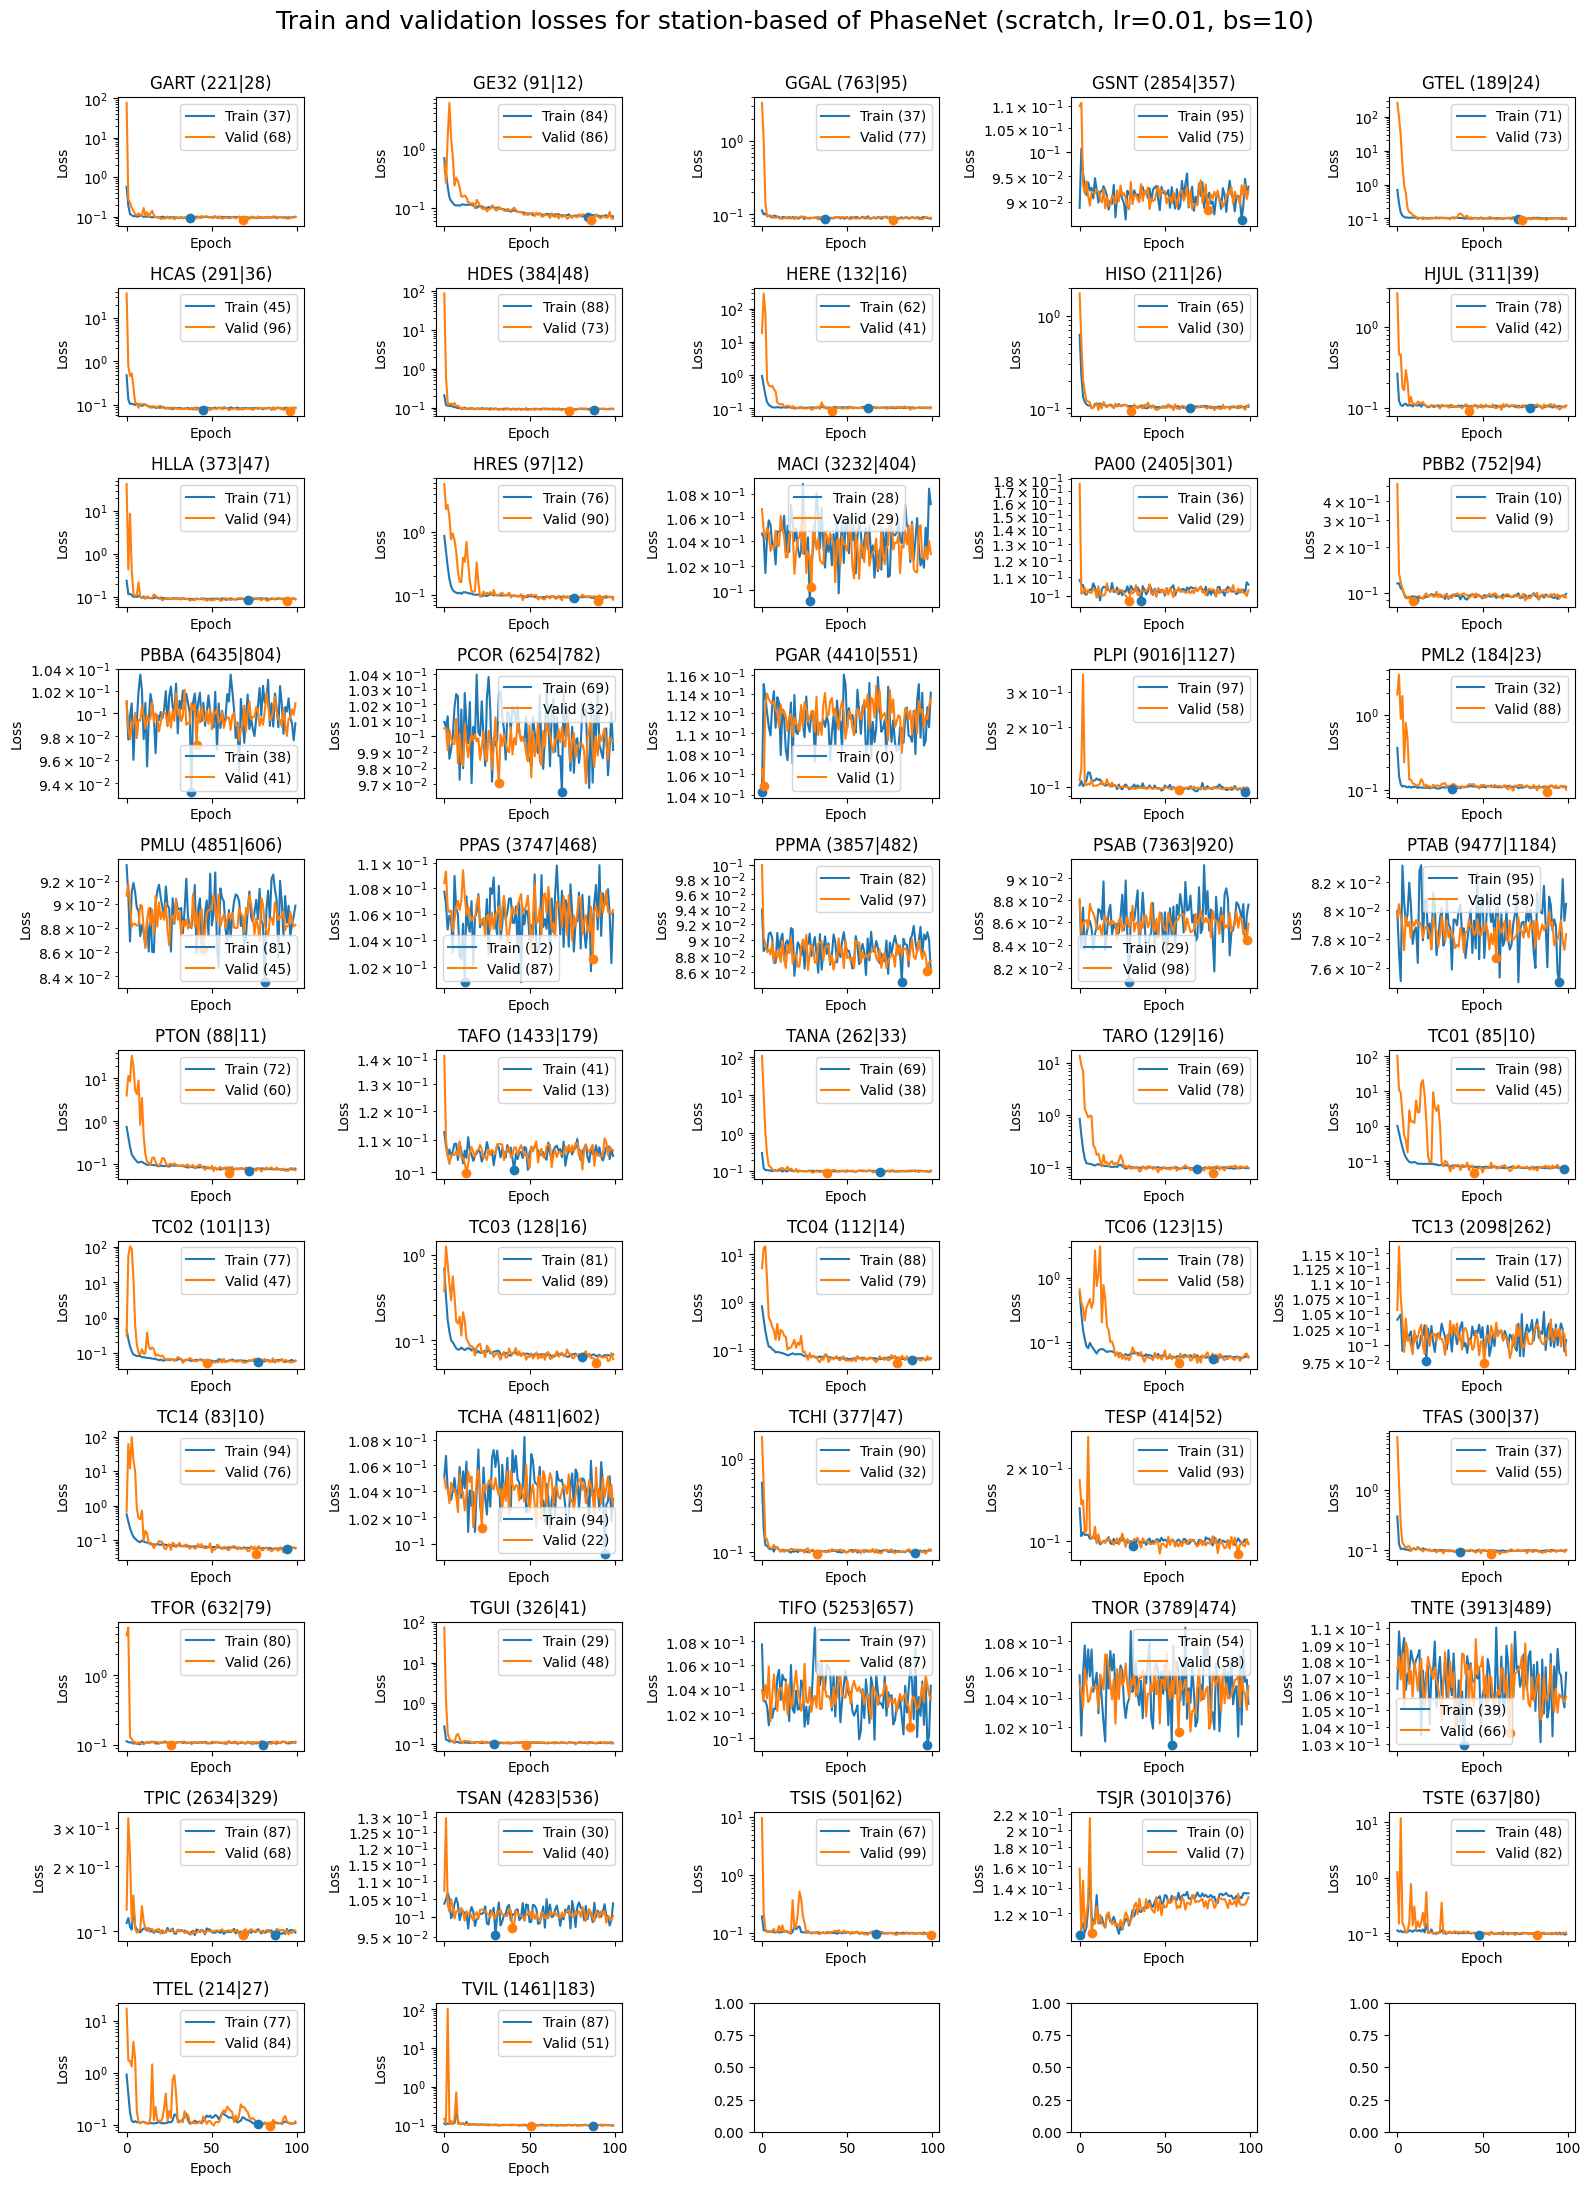

In [7]:
# Show losses for all refined models
n = len(models_)
rows, cols = ((n-1)//5)+1, min(n, 5)
fig, axs = plt.subplots(rows, cols, figsize=(16, 2*rows+0.25), sharex=True, sharey=False)
axs = axs.flatten()

for model_path, ax in zip(models_, axs):

    # Get training hyperparameters
    station_name = model_path.name.split('_')[0]
    n = station_splits_[station_name]
    hp = load_config(model_path / "config.log")
    mode = "fine" if hp["model_dir"] else "scratch"

    # Get losses and plot them
    model_loss_log_path = model_path / "loss.log"
    plot_losses(model_loss_log_path, ax=ax)
    ax.set_title(f"{station_name} ({n['train']}|{n['valid']})")

fig.suptitle(
    f"Train and validation losses for station-based of PhaseNet " \
    f"({mode}, lr={hp['learning_rate']}, bs={hp['batch_size']})", fontsize=18
)
fig.tight_layout(rect=[0, 0, 1, 1-0.25/(2*cols)])

##### Test

#### fine

In [13]:
# Define models
models_ = sorted(models_list["many_fine"][0].glob("*"))
total_stations_ = stations["many"]
stations_trained_ = sorted({str(m.name).split("_")[0] for m in models_})
stations_missing_ = sorted(set(total_stations_) - set(stations_trained_))

# Get dataset info for each station (number of train and valid samples)
station_splits_ = df_many.groupby("station")["split"].value_counts().unstack(0).loc[["train", "valid", "test"]].to_dict()

# Report stations refined
print(f"Trained stations ({len(stations_trained_)}/{len(total_stations_)}):", ", ".join(stations_trained_))
print(f"Missing stations ({len(stations_missing_)}/{len(total_stations_)}):", ", ".join(stations_missing_))
print(f"Number of folders: {len(models_)}")

Trained stations (52/52): GART, GE32, GGAL, GSNT, GTEL, HCAS, HDES, HERE, HISO, HJUL, HLLA, HRES, MACI, PA00, PBB2, PBBA, PCOR, PGAR, PLPI, PML2, PMLU, PPAS, PPMA, PSAB, PTAB, PTON, TAFO, TANA, TARO, TC01, TC02, TC03, TC04, TC06, TC13, TC14, TCHA, TCHI, TESP, TFAS, TFOR, TGUI, TIFO, TNOR, TNTE, TPIC, TSAN, TSIS, TSJR, TSTE, TTEL, TVIL
Missing stations (0/52): 
Number of folders: 52


##### Train and valid losses

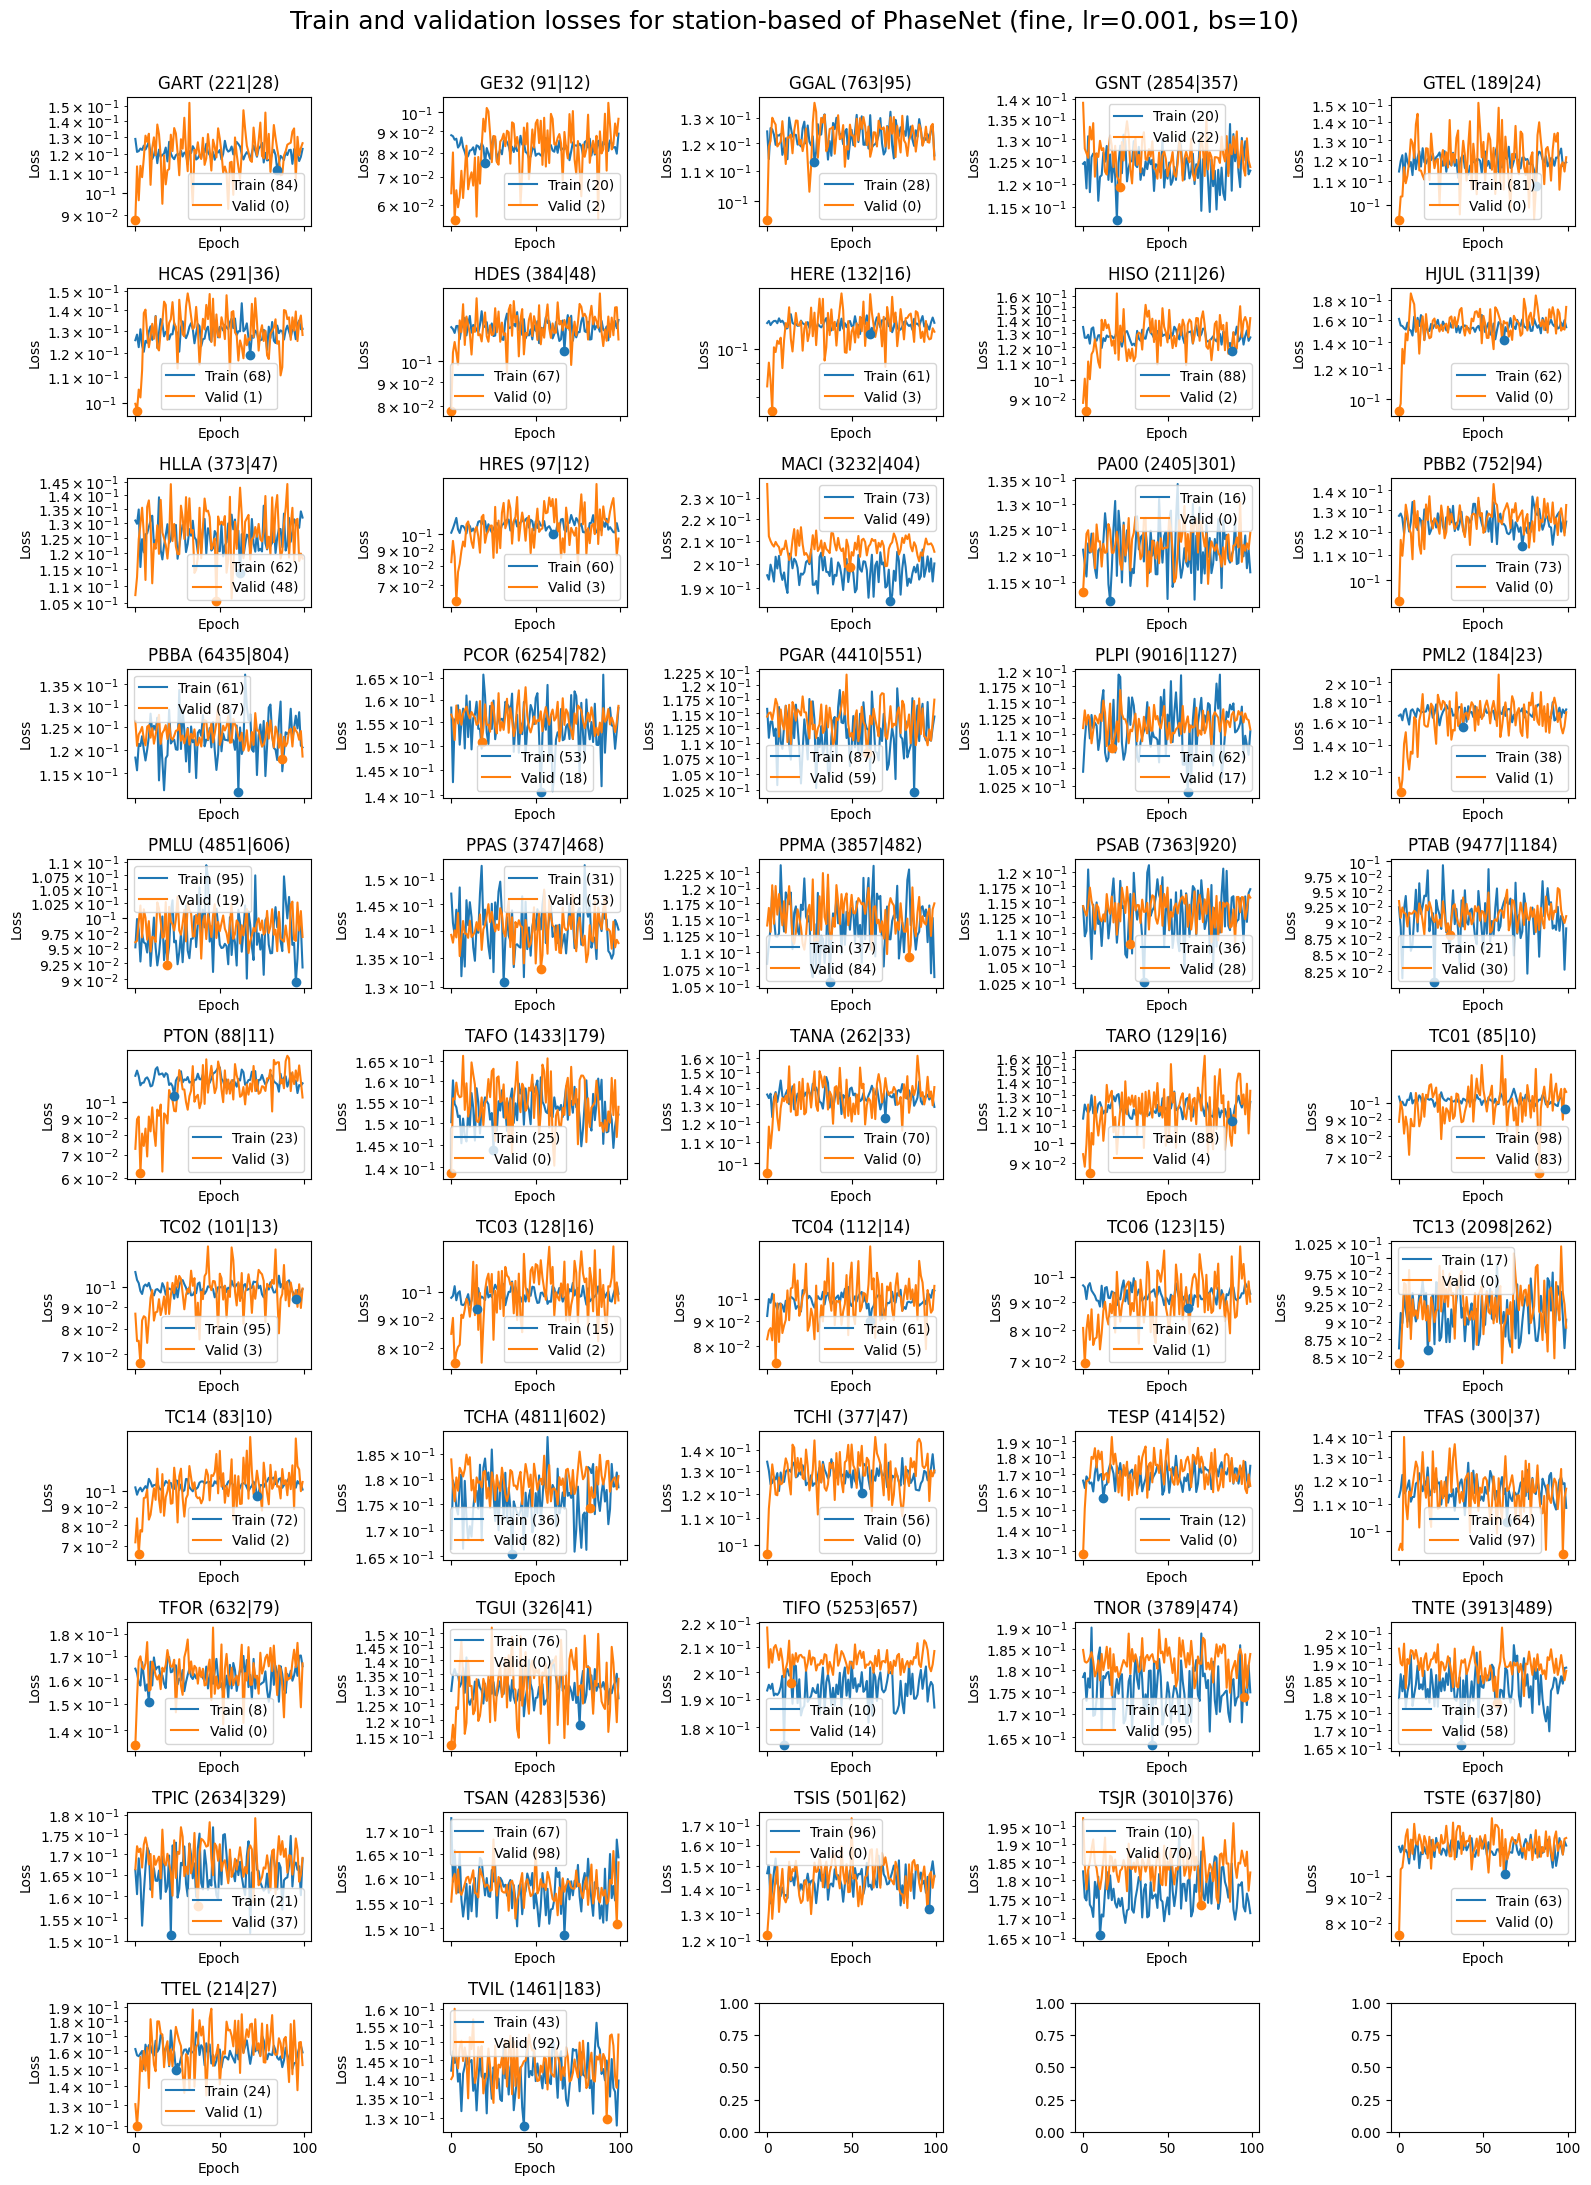

In [14]:
# Show losses for all refined models
n = len(models_)
rows, cols = ((n-1)//5)+1, min(n, 5)
fig, axs = plt.subplots(rows, cols, figsize=(16, 2*rows+0.25), sharex=True, sharey=False)
axs = axs.flatten()

for model_path, ax in zip(models_, axs):

    # Get training hyperparameters
    station_name = model_path.name.split('_')[0]
    n = station_splits_[station_name]
    hp = load_config(model_path / "config.log")
    mode = "fine" if hp["model_dir"] else "scratch"

    # Get losses and plot them
    model_loss_log_path = model_path / "loss.log"
    plot_losses(model_loss_log_path, ax=ax)
    ax.set_title(f"{station_name} ({n['train']}|{n['valid']})")

fig.suptitle(
    f"Train and validation losses for station-based of PhaseNet " \
    f"({mode}, lr={hp['learning_rate']}, bs={hp['batch_size']})", fontsize=18
)
fig.tight_layout(rect=[0, 0, 1, 1-0.25/(2*cols)])

Trained stations (52/52): GART, GE32, GGAL, GSNT, GTEL, HCAS, HDES, HERE, HISO, HJUL, HLLA, HRES, MACI, PA00, PBB2, PBBA, PCOR, PGAR, PLPI, PML2, PMLU, PPAS, PPMA, PSAB, PTAB, PTON, TAFO, TANA, TARO, TC01, TC02, TC03, TC04, TC06, TC13, TC14, TCHA, TCHI, TESP, TFAS, TFOR, TGUI, TIFO, TNOR, TNTE, TPIC, TSAN, TSIS, TSJR, TSTE, TTEL, TVIL
Missing stations (0/52): 
Number of folders: 52
Trained stations (52/52): GART, GE32, GGAL, GSNT, GTEL, HCAS, HDES, HERE, HISO, HJUL, HLLA, HRES, MACI, PA00, PBB2, PBBA, PCOR, PGAR, PLPI, PML2, PMLU, PPAS, PPMA, PSAB, PTAB, PTON, TAFO, TANA, TARO, TC01, TC02, TC03, TC04, TC06, TC13, TC14, TCHA, TCHI, TESP, TFAS, TFOR, TGUI, TIFO, TNOR, TNTE, TPIC, TSAN, TSIS, TSJR, TSTE, TTEL, TVIL
Missing stations (0/52): 
Number of folders: 52


/tmp/ipykernel_290840/776847300.py:89: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  ax.legend(["Train scratch", "_nolegend_", "Valid scratch", "_nolegend_", "Train fine", "_nolegend_", "Valid fine", "_nolegend_"])


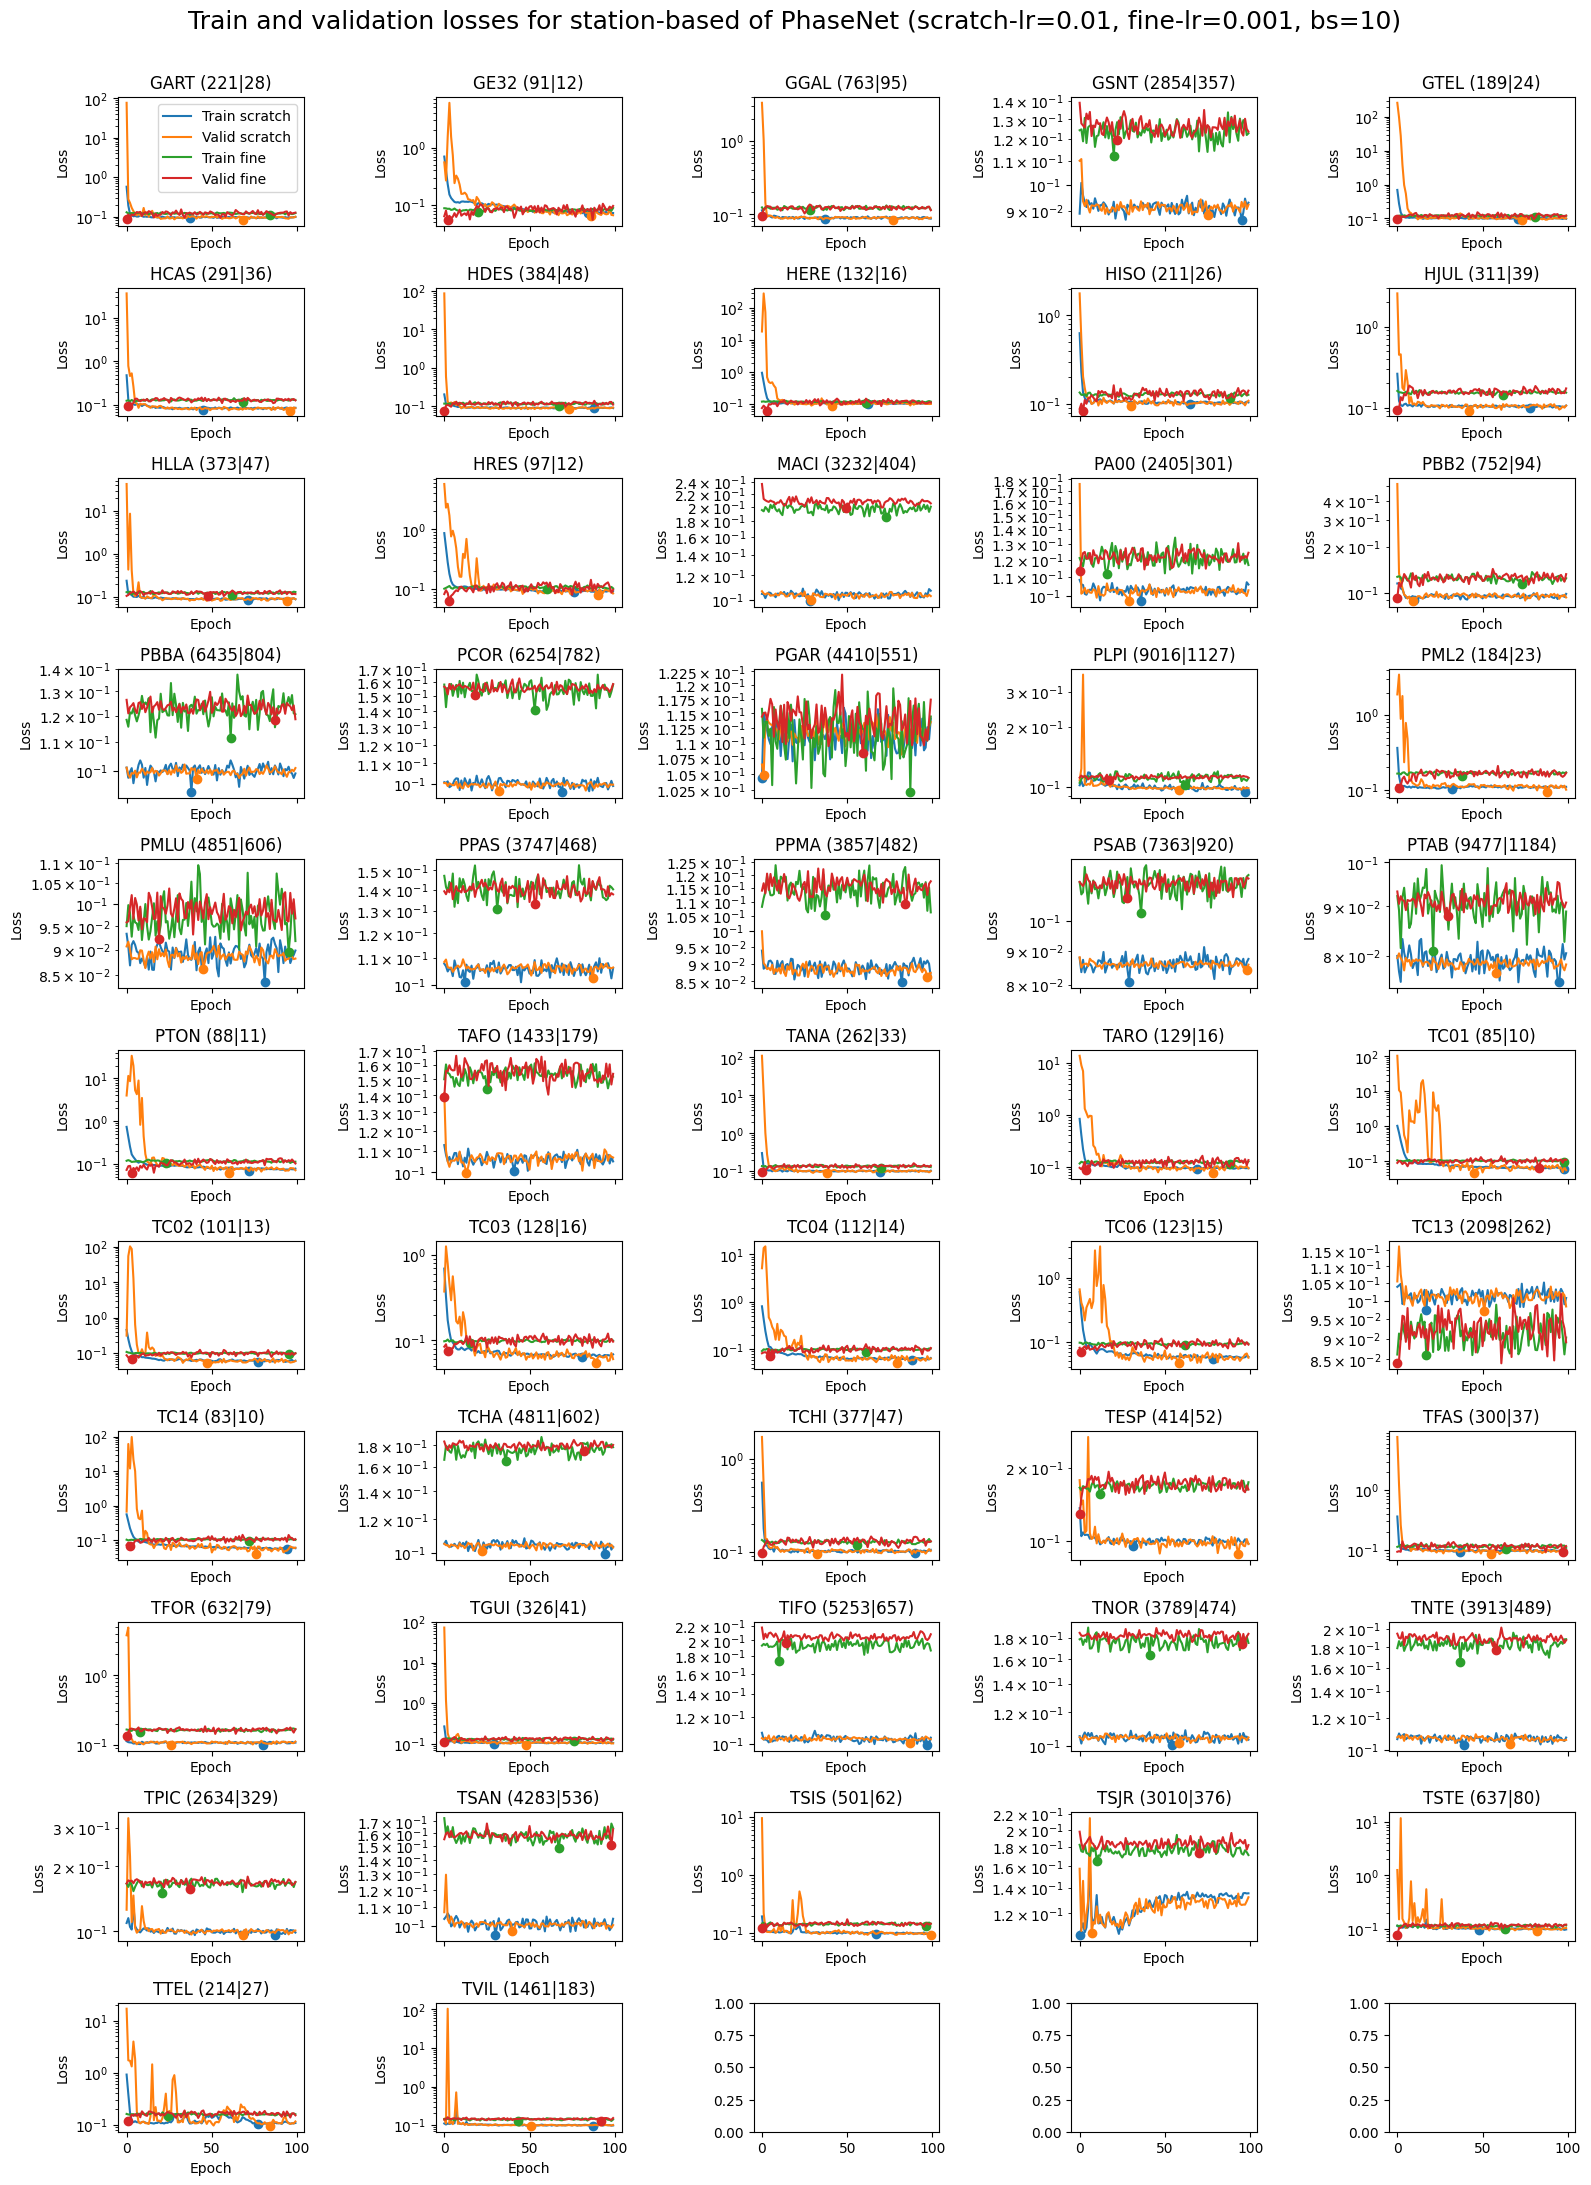

In [18]:
# Define models
models_ = sorted(models_list["many_raw"][0].glob("*"))
total_stations_ = stations["many"]
stations_trained_ = sorted({str(m.name).split("_")[0] for m in models_})
stations_missing_ = sorted(set(total_stations_) - set(stations_trained_))

# Get dataset info for each station (number of train and valid samples)
station_splits_ = df_many.groupby("station")["split"].value_counts().unstack(0).loc[["train", "valid", "test"]].to_dict()

# Report stations refined
print(f"Trained stations ({len(stations_trained_)}/{len(total_stations_)}):", ", ".join(stations_trained_))
print(f"Missing stations ({len(stations_missing_)}/{len(total_stations_)}):", ", ".join(stations_missing_))
print(f"Number of folders: {len(models_)}")




# Show losses for all refined models
n = len(models_)
rows, cols = ((n-1)//5)+1, min(n, 5)
fig, axs = plt.subplots(rows, cols, figsize=(16, 2*rows+0.25), sharex=True, sharey=False)
axs = axs.flatten()

for model_path, ax in zip(models_, axs):

    # Get training hyperparameters
    station_name = model_path.name.split('_')[0]
    n = station_splits_[station_name]
    hp = load_config(model_path / "config.log")
    mode = "fine" if hp["model_dir"] else "scratch"

    # Get losses and plot them
    model_loss_log_path = model_path / "loss.log"
    plot_losses(model_loss_log_path, ax=ax)
    ax.set_title(f"{station_name} ({n['train']}|{n['valid']})")

# fig.suptitle(
#     f"Train and validation losses for station-based of PhaseNet " \
#     f"({mode}, lr={hp['learning_rate']}, bs={hp['batch_size']})", fontsize=18
# )
# fig.tight_layout(rect=[0, 0, 1, 1-0.25/(2*cols)])









# Define models
models_ = sorted(models_list["many_fine"][0].glob("*"))
total_stations_ = stations["many"]
stations_trained_ = sorted({str(m.name).split("_")[0] for m in models_})
stations_missing_ = sorted(set(total_stations_) - set(stations_trained_))

# Get dataset info for each station (number of train and valid samples)
station_splits_ = df_many.groupby("station")["split"].value_counts().unstack(0).loc[["train", "valid", "test"]].to_dict()

# Report stations refined
print(f"Trained stations ({len(stations_trained_)}/{len(total_stations_)}):", ", ".join(stations_trained_))
print(f"Missing stations ({len(stations_missing_)}/{len(total_stations_)}):", ", ".join(stations_missing_))
print(f"Number of folders: {len(models_)}")




# # Show losses for all refined models
# n = len(models_)
# rows, cols = ((n-1)//5)+1, min(n, 5)
# fig, axs = plt.subplots(rows, cols, figsize=(16, 2*rows+0.25), sharex=True, sharey=False)
# axs = axs.flatten()

for model_path, ax in zip(models_, axs):

    # Get training hyperparameters
    station_name = model_path.name.split('_')[0]
    n = station_splits_[station_name]
    hp = load_config(model_path / "config.log")
    mode = "fine" if hp["model_dir"] else "scratch"

    # Get losses and plot them
    model_loss_log_path = model_path / "loss.log"
    plot_losses(model_loss_log_path, ax=ax)
    ax.set_title(f"{station_name} ({n['train']}|{n['valid']})")
    if ax != axs[0]:
        ax.legend().set_visible(False)
    else:
        ax.legend(["Train scratch", "_nolegend_", "Valid scratch", "_nolegend_", "Train fine", "_nolegend_", "Valid fine", "_nolegend_"])

# fig.suptitle(
#     f"Train and validation losses for station-based of PhaseNet " \
#     f"({mode}, lr={hp['learning_rate']}, bs={hp['batch_size']})", fontsize=18
# )




fig.suptitle(
    f"Train and validation losses for station-based of PhaseNet " \
    f"(scratch-lr=0.01, fine-lr=0.001, bs={hp['batch_size']})", fontsize=18
)
fig.tight_layout(rect=[0, 0, 1, 1-0.25/(2*cols)])


In [19]:
ax.get_legend_handles_labels()

([<matplotlib.lines.Line2D at 0x7fe21fcc8f50>,
 ['Train (87)', 'Valid (51)', 'Train (43)', 'Valid (92)'])

### FEW

In [20]:
# Define models
models_ = models_list["few"]
total_stations_ = stations["few"]
stations_trained_ = sorted({str(m.name).split("_")[0] for m in models_})
stations_missing_ = sorted(set(total_stations_) - set(stations_trained_))

# Get dataset info for each station (number of train and valid samples)
station_splits_ = df_few.groupby("station")["split"].value_counts().unstack(0).loc[["train", "valid", "test"]].to_dict()

# Report stations refined
# print(f"Trained stations ({len(stations_trained_)}/{len(total_stations_)}):", ", ".join(stations_trained_))
# print(f"Missing stations ({len(stations_missing_)}/{len(total_stations_)}):", ", ".join(stations_missing_))
print(f"Number of folders: {len(models_)}")

Number of folders: 6


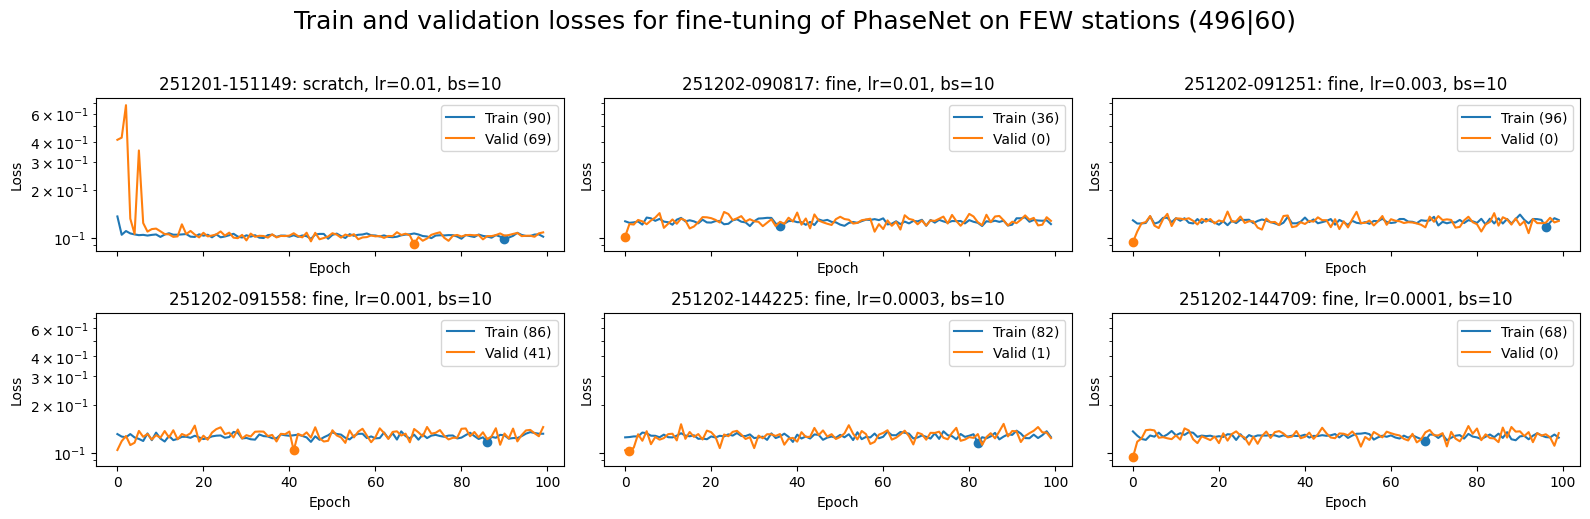

In [21]:
# Show losses for all refined models
n = len(models_)
rows, cols = ((n-1)//3)+1, min(n, 3)
fig, axs = plt.subplots(rows, cols, figsize=(16, 2.5*rows+0.25), sharex=True, sharey=True)
axs = axs.flatten()

for model_path, ax in zip(models_, axs):

    # Get training hyperparameters
    datetime, _, *args = model_path.name.split('_')
    hp = load_config(model_path / "config.log")
    mode = "fine" if hp["model_dir"] else "scratch"

    # Get losses and plot them
    model_loss_log_path = model_path / "loss.log"
    plot_losses(model_loss_log_path, ax=ax)
    ax.set_title(f"{datetime}: {mode}, lr={hp['learning_rate']}, bs={hp['batch_size']}")


fig.suptitle("Train and validation losses for fine-tuning of PhaseNet on FEW stations (496|60)", fontsize=18)
fig.tight_layout(rect=[0, 0, 1, 1-0.25/(2*cols)])

### ALL splits

In [22]:
# Define models
models_ = models_list["all"]
total_stations_ = stations["few"]
# stations_trained_ = sorted({str(m.name).split("_")[0] for m in models_})
# stations_missing_ = sorted(set(total_stations_) - set(stations_trained_))

# Get dataset info for each station (number of train and valid samples)
station_splits_ = df_many.groupby("station")["split"].value_counts().unstack(0).loc[["train", "valid", "test"]].to_dict()

# Report stations refined
# print(f"Trained stations ({len(stations_trained_)}/{len(total_stations_)}):", ", ".join(stations_trained_))
# print(f"Missing stations ({len(stations_missing_)}/{len(total_stations_)}):", ", ".join(stations_missing_))
print(f"Number of folders: {len(models_)}")

Number of folders: 4


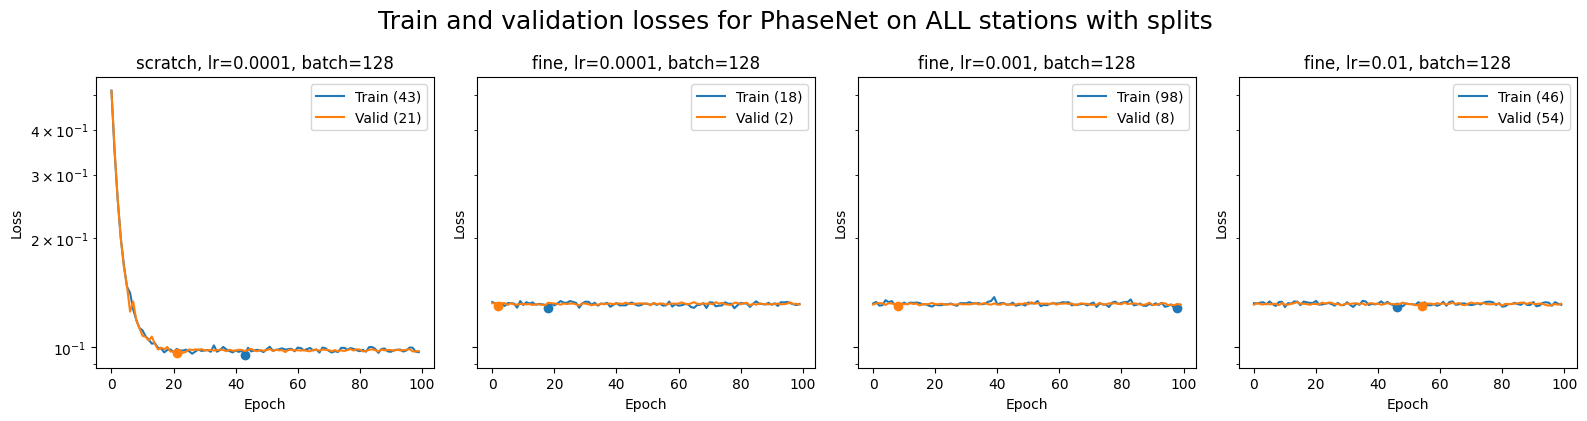

In [23]:
# Show losses for all refined models
n = len(models_)
rows, cols = ((n-1)//4)+1, min(n, 4)
fig, axs = plt.subplots(rows, cols, figsize=(16, 2+2*rows+0.25), sharex=True, sharey=True)
axs = axs.flatten()

for model_path, ax in zip(models_, axs):
    # datetime, *_ = model_path.name
    model_loss_log_path = model_path / "loss.log"
    model_config = load_config(model_loss_log_path.parent / "config.log")
    mode = "fine" if model_config["model_dir"] else "scratch"
    plot_losses(model_loss_log_path, ax=ax)
    ax.set_title(f"{mode}, lr={model_config['learning_rate']}, batch={model_config['batch_size']}")


fig.suptitle("Train and validation losses for PhaseNet on ALL stations with splits", fontsize=18)
# fig.tight_layout(rect=[0, 0, 1, 1-0.25/(2*cols)])
fig.tight_layout()

## Tests

## Analysis

### Training

#### Global
- Training from scratch finds better train/valid losses

#### Many (raw)
- TSJR seems to worsen over time

#### Many (fine)
- Stations with fewer samples show an increment of validation loss at the first epochs. This could be due to dropout, but it is not activated...

#### Few
- The lr does not have any effect




### Tests

In [ ]:
# # Generate commands to test all models for "many raw"
# for model_dir in sorted([*Path("/workspaces/PhaseNet_manu/log/MANY/251201_many_raw_0.01").glob("*/models")]):
#     station = model_dir.parent.name.split("_")[0]
#     data_list = list(Path("dataset/involcan/station_lists").glob(f"involcan_train_many_{station}.csv"))[0]
#     results_dir = os.path.join("results", *str(model_dir.parent).split("/")[-3:])

#     s = f"python phasenet/predict.py --model_dir={model_dir} --result_dir={results_dir} --data_list={data_list} --data_dir=dataset/involcan/involcan_data --batch_size=128 --format=numpy --save_prob"
#     print(s)

python phasenet/predict.py --model_dir=/workspaces/PhaseNet_manu/log/MANY/251201_many_raw_0.01/GART_251119-155445/models --result_dir=results/MANY/251201_many_raw_0.01/GART_251119-155445 --data_list=dataset/involcan/station_lists/involcan_train_many_GART.csv --data_dir=dataset/involcan/involcan_data --batch_size=128 --format=numpy --save_prob
python phasenet/predict.py --model_dir=/workspaces/PhaseNet_manu/log/MANY/251201_many_raw_0.01/GE32_251119-161725/models --result_dir=results/MANY/251201_many_raw_0.01/GE32_251119-161725 --data_list=dataset/involcan/station_lists/involcan_train_many_GE32.csv --data_dir=dataset/involcan/involcan_data --batch_size=128 --format=numpy --save_prob
python phasenet/predict.py --model_dir=/workspaces/PhaseNet_manu/log/MANY/251201_many_raw_0.01/GGAL_251119-162554/models --result_dir=results/MANY/251201_many_raw_0.01/GGAL_251119-162554 --data_list=dataset/involcan/station_lists/involcan_train_many_GGAL.csv --data_dir=dataset/involcan/involcan_data --batch_s

In [ ]:
# # Generate commands to test all models for "many fine"
# for model_dir in sorted([*Path("/workspaces/PhaseNet_manu/log/MANY/251202_many_fine_0.001").glob("*/models")]):
#     station = model_dir.parent.name.split("_")[0]
#     data_list = list(Path("dataset/involcan/station_lists").glob(f"involcan_train_many_{station}.csv"))[0]
#     results_dir = os.path.join("results", *str(model_dir.parent).split("/")[-3:])

#     s = f"python phasenet/predict.py --model_dir={model_dir} --result_dir={results_dir} --data_list={data_list} --data_dir=dataset/involcan/involcan_data --batch_size=128 --format=numpy --save_prob"
#     print(s)

python phasenet/predict.py --model_dir=/workspaces/PhaseNet_manu/log/MANY/251202_many_fine_0.001/GART_251202-150029/models --result_dir=results/MANY/251202_many_fine_0.001/GART_251202-150029 --data_list=dataset/involcan/station_lists/involcan_train_many_GART.csv --data_dir=dataset/involcan/involcan_data --batch_size=128 --format=numpy --save_prob
python phasenet/predict.py --model_dir=/workspaces/PhaseNet_manu/log/MANY/251202_many_fine_0.001/GE32_251202-150136/models --result_dir=results/MANY/251202_many_fine_0.001/GE32_251202-150136 --data_list=dataset/involcan/station_lists/involcan_train_many_GE32.csv --data_dir=dataset/involcan/involcan_data --batch_size=128 --format=numpy --save_prob
python phasenet/predict.py --model_dir=/workspaces/PhaseNet_manu/log/MANY/251202_many_fine_0.001/GGAL_251202-150211/models --result_dir=results/MANY/251202_many_fine_0.001/GGAL_251202-150211 --data_list=dataset/involcan/station_lists/involcan_train_many_GGAL.csv --data_dir=dataset/involcan/involcan_da

### Load data

In [6]:
# Use the predict script with the `--save-probs` flag. Predictions saved to `--result_dir`

# Define paths
test_list_file = dataset_dir / "involcan_train50.csv"
prediction_dir = Path("results/debug_predict_base-figures/")  # Same as `--result_dir`

assert prediction_dir.exists() and test_list_file.exists()

##### Load test list (csv)

In [7]:
# List of test files
df_dataset = pd.read_csv(test_list_file, sep="\t", index_col=0)  # More info on npz files

# Load itp, its
# df_dataset[["p_idx", "s_idx"]]

##### Load test dataset

In [8]:
batch_size = 1
data_reader = DataReader_pred(
    format="numpy",
    data_dir=dataset_dir/"involcan_data",
    data_list=test_list_file,
    # hdf5_file=args.hdf5_file,
    # hdf5_group=args.hdf5_group,
    # amplitude=args.amplitude,
    # highpass_filter=args.highpass_filter,
    # response_xml=args.response_xml,
    # sampling_rate=args.sampling_rate
)

i = 0  # for an example
npz_files = data_reader.data_list  # pd.Series with names of npz files
data_sample = data_reader[i]  # Select data by index
# data_sample = data_reader[pd.Index(data_reader.data_list).get_loc("C7.TAFO..HH.20161129-232439.npz")]  # Select data by index

# Show contents
[_.shape if isinstance(_, np.ndarray) else _ for _ in data_sample]  # d[0].shape, d[1].shape, d[2], d[3]

[(12000, 1, 3),
 (12000, 1, 3),
 'C7.TAFO..HH.20161122-104531.npz',
 '1970-01-01T00:00:00.000',
 'C7.TAFO..HH.20161122-104531.npz']

In [9]:
# Notes

# -----------------------------------------------------------------------
# **DataReader_pred** devuelve... con todos los puntos (12000) normalizados (y raw si amplitude=True)
#     if self.amplitude:
#         return (sample, raw_amp, base_name, t0, station_id)
#     else:
#         return (sample, base_name, t0, station_id)
# 
# **DataReader_test** devuelve... tras cortar las waveforms entre [5000, 8000]
#   return (sample, target, base_name, itp_list, its_list)
# 
# **DataReader_train** devuelve... tras el corte entre [5000, 8000], shifted, stacked, normalized, and random noise added
#   return (sample.astype(self.dtype), target.astype(self.dtype), base_name)
# 
# To avoid cutting the data, use dataset and batch as follows:
#       dataset = data_reader.dataset(batch_size=5)
#       batch = tf.compat.v1.data.make_one_shot_iterator(dataset).get_next()
# -----------------------------------------------------------------------

##### Load waveforms and info (npz)

In [9]:
# Load waveforms from npz (just one here)
# df_all.query("fname == 'C7.TAFO..HH.20161122-104531.npz'")
npz_file = npz_files[i]
event_data = np.load(f"{dataset_dir / 'involcan_data' / data_sample[2]}")
event_data["data"]  # data, p_idx, s_idx, p_time, s_time  # <- [*waveforms.keys()]

# Important data
event_data["data"]  # Same as raw_amp in dataset
p_idx = int(event_data["p_idx"])
p_time = pd.Timestamp(str(event_data["p_time"]))
dt = pd.Timedelta(float(event_data["dt"]), unit="sec")
t0 = p_time - p_idx*dt  # Start_time of waveform


In [10]:
# Also, using the DataReader method read_numpy
meta = data_reader.read_numpy(dataset_dir / 'involcan_data' / npz_files[0])

##### Load predictions (csv and h5)

In [11]:
df_picks = pd.read_csv(prediction_dir / "picks.csv")
picks = df_picks.to_dict(orient="records")
named_picks = {_["file_name"]: {"P": [], "S": []} for _ in picks}

# Show data
print(*picks[:5], sep="\n")
print(*[(k, v) for i, (k, v) in enumerate(named_picks.items()) if i<5], sep="\n")
df_picks.head()
#   station_id	begin_time	    phase_index	phase_time	        phase_score	phase_type	file_name
# 3	73	1970-01-01T00:00:00.000	5955	1970-01-01T00:00:59.550	0.325	P	IU.MACI..HH.20161129-232439.npz

{'station_id': 67, 'begin_time': '1970-01-01T00:00:00.000', 'phase_index': 5704, 'phase_time': '1970-01-01T00:00:57.040', 'phase_score': 0.746, 'phase_type': 'P', 'file_name': 'C7.TAFO..HH.20161122-104531.npz'}
{'station_id': 67, 'begin_time': '1970-01-01T00:00:00.000', 'phase_index': 6105, 'phase_time': '1970-01-01T00:01:01.050', 'phase_score': 0.466, 'phase_type': 'P', 'file_name': 'C7.TAFO..HH.20161122-104531.npz'}
{'station_id': 67, 'begin_time': '1970-01-01T00:00:00.000', 'phase_index': 6476, 'phase_time': '1970-01-01T00:01:04.760', 'phase_score': 0.684, 'phase_type': 'S', 'file_name': 'C7.TAFO..HH.20161122-104531.npz'}
{'station_id': 67, 'begin_time': '1970-01-01T00:00:00.000', 'phase_index': 6000, 'phase_time': '1970-01-01T00:01:00.000', 'phase_score': 0.94, 'phase_type': 'P', 'file_name': 'C7.TAFO..HH.20161129-125837.npz'}
{'station_id': 67, 'begin_time': '1970-01-01T00:00:00.000', 'phase_index': 6458, 'phase_time': '1970-01-01T00:01:04.580', 'phase_score': 0.721, 'phase_type':

,station_id,begin_time,phase_index,phase_time,phase_score,phase_type,file_name
0,67,1970-01-01T00:00:00.000,5704,1970-01-01T00:00:57.040,0.746,P,C7.TAFO..HH.20161122-104531.npz
1,67,1970-01-01T00:00:00.000,6105,1970-01-01T00:01:01.050,0.466,P,C7.TAFO..HH.20161122-104531.npz
2,67,1970-01-01T00:00:00.000,6476,1970-01-01T00:01:04.760,0.684,S,C7.TAFO..HH.20161122-104531.npz
3,67,1970-01-01T00:00:00.000,6000,1970-01-01T00:01:00.000,0.940,P,C7.TAFO..HH.20161129-125837.npz
4,67,1970-01-01T00:00:00.000,6458,1970-01-01T00:01:04.580,0.721,S,C7.TAFO..HH.20161129-125837.npz


In [12]:
# Load data predictions from h5 file
predictions = {}

with h5py.File(prediction_dir / 'result.h5', 'r') as f:
    h5_data = f['prob']
    for name, data in h5_data.items():
        if name in predictions.keys():
            print(f"Overwriten '{name}'")
        predictions[name] = data[:]
        # data.attrs.keys()  # If empty, no custom attributes
    # data.visititems(lambda a, b: print(b))

names = [*predictions.keys()]
predictions = {k: predictions[k] for k in sorted(names)}

# Check 
# [*predictions.values()][0].shape
predictions[df_picks.loc[0, "file_name"].split(".npz")[0]].shape

(12000, 1, 3)

##### Extract picks from predictions

In [13]:
# Get picks from probability predictions
# Note: there is no need, since this info is already in the picks.csv under `phase_index`

args = argparse.Namespace(sampling_rate=100, min_p_prob=0.3, min_s_prob=0.3, mpd=50, amplitude=False, pre_sec=1, post_sec=4)
picks = extract_picks(
    preds=np.stack([v for v in predictions.values()])[:5],
    file_names=np.stack([v for v in predictions.keys()])[:5],
    station_ids=[*predictions.keys()][:5],
    begin_times=None,
    config=args,
    waveforms=None,
    use_amplitude=args.amplitude,
    dt=1.0 / args.sampling_rate,
)
len(picks)

# true_picks = convert_true_picks(fname_batch, itp_batch, its_batch)

7

In [14]:
# picks = df_picks.to_dict(orient="records")
named_picks = {_["file_name"]: {"P": [], "S": []} for _ in picks}
print(*[(k, v) for i, (k, v) in enumerate(named_picks.items()) if i<5], sep="\n")

('C7.TAFO..HH.20161122-104531', {'P': [], 'S': []})
('C7.TAFO..HH.20161129-125837', {'P': [], 'S': []})
('C7.TAFO..HH.20161204-230057', {'P': [], 'S': []})


### Plot data

In [16]:
# Select an entry
name = names[i]
waveform = event_data["data"][:, np.newaxis, :]  # meta["data"]  # Viene de `involcan_data`
phase_list = [[[int(event_data[_])]] for _ in ["p_idx", "s_idx"]]  # [meta["itp"], meta["its"]]
itp, its = phase_list[0][0], phase_list[1][0]
label = data_reader.generate_label(meta["data"], phase_list=phase_list)

pred = predictions[name]
# picks  (viene de las predicciones en df_picks en picks.csv o calculado con `extract_picks` de las probs en el h5)
itp_pred = [_["phase_index"] for _ in picks if _["file_name"]==name and _["phase_type"]=="P"]
its_pred = [_["phase_index"] for _ in picks if _["file_name"]==name and _["phase_type"]=="S"]

##### Manually

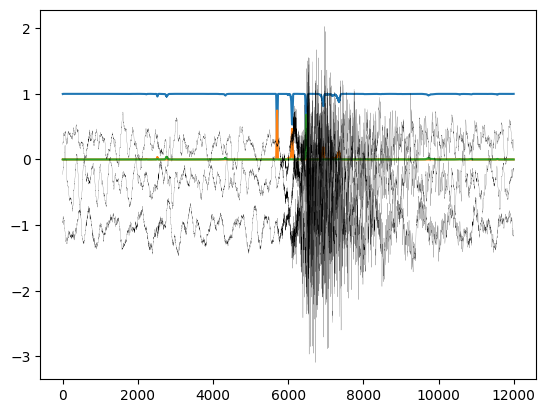

In [17]:
# Manually plot waveform and predictions
plt.plot(pred[:,0,0])  # Noise
plt.plot(pred[:,0,1])  # P-wave
plt.plot(pred[:,0,2])  # S-wave
plt.plot(event_data["data"]/10000, "k", lw=0.1)


##### plot_waveform(...)

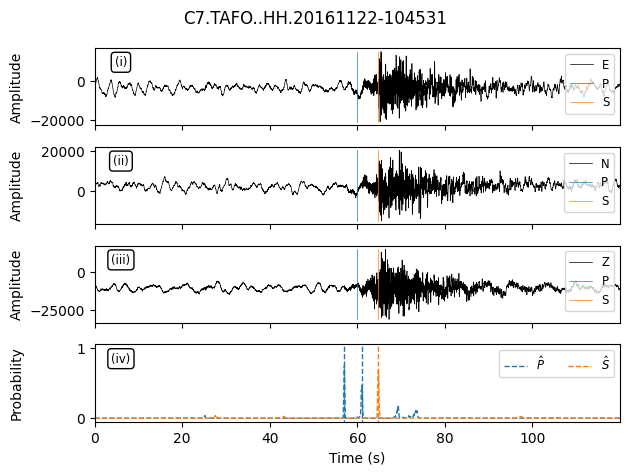

In [18]:
# Plot waveform and probabilities with PhaseNet library
fig = plot_waveform(
    data=event_data['data'].reshape([12000, 1, 3]),
    pred=pred,
    # label=label,
    itp=itp,  # List of P-phase indices
    its=its,  # List of S-phase indices
    itp_pred=itp_pred,
    its_pred=its_pred,
    fname="ddd",
    figure_dir="results",
    close_figure=False,
)
# fig.get_axes()[-1].plot(np.linspace(0, 119.99000000000001, len(preds_true[0][1][:,0,:])), preds_true[0][1][:,0,:], 'k', lw=0.5)
fig.suptitle(name)
fig.tight_layout()

### Metrics

In [4]:
# Input parameters
test_list_file = dataset_dir / "involcan_train50.csv"
prediction_dir = Path("results/debug_predict_base-figures/")  # Same as `--result_dir`
tolerance = 1.5  # in seconds
unique = True
dt = 0.01  # Sampling period in seconds (freq is 100Hz)


df_results, global_metrics = analyze_results(test_list_file, prediction_dir, tolerance, dt, unique, verbose=True)
df_results.head()

Total events:  P =  50; S =  50
Total picks:   P =  36; S =  31

               precision  recall    f-1
P-wave metrics:    0.889   0.640  0.744
S-wave metrics:    0.871   0.540  0.667

Confusion matrix (P phase)
[[32.  4.]
 [18. nan]]

Confusion matrix (S phase)
[[27.  4.]
 [23. nan]]

                                network station location_code  p_idx  \
fname                                                                  
C7.TAFO..HH.20161122-104531.npz      C7    TAFO            --   6000   
C7.TAFO..HH.20161129-125837.npz      C7    TAFO            --   6000   
C7.TAFO..HH.20161129-232439.npz      C7    TAFO            --   6000   
C7.TAFO..HH.20161204-230057.npz      C7    TAFO            --   6000   
C7.TAFO..HH.20161206-232537.npz      C7    TAFO            --   6000   

                                                     p_time p_remark  \
fname                                                                  
C7.TAFO..HH.20161122-104531.npz  2016-11-22T10:45:41.106129    

,network,station,location_code,p_idx,p_time,p_remark,p_weight,s_idx,s_time,s_remark,...,S_miss,PasP,SasP,NasP,PasS,SasS,NasS,PasN,SasN,NasN
fname,,,,,,,,,,,,,,,,,,,,,
C7.TAFO..HH.20161122-104531.npz,C7,TAFO,--,6000,2016-11-22T10:45:41.106129,P,3,6478,2016-11-22T10:45:45.88214,S,...,[],"[(6000, 6105)]",[],[5704],[],"[(6478, 6476)]",[],[],[],NaN
C7.TAFO..HH.20161129-125837.npz,C7,TAFO,--,6000,2016-11-29T12:58:42.599177,P,2,6453,2016-11-29T12:58:47.131027,S,...,[],"[(6000, 6000)]",[],[],[],"[(6453, 6458)]",[],[],[],NaN
C7.TAFO..HH.20161129-232439.npz,C7,TAFO,--,6000,2016-11-29T23:24:43.708727,P,3,6285,2016-11-29T23:24:46.556605,S,...,[6285],[],[],[],[],[],[],[6000],[6285],NaN
C7.TAFO..HH.20161204-230057.npz,C7,TAFO,--,6000,2016-12-04T23:01:02.48817,P,1,6263,2016-12-04T23:01:05.120036,S,...,[6263],"[(6000, 5995)]",[],[],[],[],[6592],[],[6263],NaN
C7.TAFO..HH.20161206-232537.npz,C7,TAFO,--,6000,2016-12-06T23:25:43.096351,P,2,6376,2016-12-06T23:25:46.85374,S,...,[6376],[],[],[],[],[],[],[6000],[6376],NaN


In [5]:
# Global metrics from DataFrame
mcols = {"Pp": ["PasP", "SasP", "NasP"], "Pr": ["PasP", "PasS", "PasN"], "Sp": ["SasS", "PasS", "NasS"], "Sr": ["SasS", "SasP", "SasN"]}
p_precision = df_results["PasP"].apply(len).sum() / df_results.apply(lambda r: sum([len(r[_]) for _ in mcols["Pp"]]), axis=1).sum()
p_recall = df_results["PasP"].apply(len).sum() / df_results.apply(lambda r: sum([len(r[_]) for _ in mcols["Pr"]]), axis=1).sum()
p_f1 = 2*p_precision*p_recall / (p_precision+p_recall)
s_precision = df_results["SasS"].apply(len).sum() / df_results.apply(lambda r: sum([len(r[_]) for _ in mcols["Sp"]]), axis=1).sum()
s_recall = df_results["SasS"].apply(len).sum() / df_results.apply(lambda r: sum([len(r[_]) for _ in mcols["Sr"]]), axis=1).sum()
s_f1 = 2*s_precision*s_recall / (s_precision+s_recall)
print(p_precision, p_recall, p_f1, s_precision, s_recall, s_f1)

# Global metrics to DataFrame
df_global = pd.DataFrame(pd.DataFrame(global_metrics).unstack()).T
df_global.index = ["global"]
df_global

# Metrics by station
df_results_station = group_results(df_results, "station")  # station, network, 
df_results_station = df_results_station.stack().unstack(level=[-2,-1])
df_results_station

# Final DataFrame with metrics
df_results_grouped = pd.concat([
    df_global,
    df_results_station
])
df_results_grouped

0.8888888888888888 0.64 0.7441860465116279 0.8709677419354839 0.54 0.6666666666666666


P                             S                    
       precision    recall        f1 precision    recall        f1
global  0.888889  0.640000  0.744186  0.870968  0.540000  0.666667
TAFO    0.750000  0.600000  0.666667  0.666667  0.400000  0.500000
TCHI    1.000000  0.800000  0.888889  1.000000  0.600000  0.750000
TESP    1.000000  0.666667  0.800000  0.666667  0.666667  0.666667
TFAS    1.000000  1.000000  1.000000  1.000000  1.000000  1.000000
TNOR    0.666667  0.500000  0.571429  1.000000  0.500000  0.666667
TPAR    0.000000  0.000000  0.000000  1.000000  0.500000  0.666667
TSIS    0.500000  0.333333  0.400000  1.000000  0.333333  0.500000
TSJR    1.000000  0.700000  0.823529  1.000000  0.700000  0.823529
TSTE    1.000000  1.000000  1.000000  0.500000  0.500000  0.500000
TVIL    0.800000  0.666667  0.727273  0.750000  0.500000  0.600000
MACI    1.000000  0.666667  0.800000  1.000000  0.444444  0.615385

In [60]:
results_to_evaluate

[PosixPath('results/ALL/251203-165142_all_raw_0.0001'),
 PosixPath('results/ALL/251204-090852_all_fine_0.0001'),
 PosixPath('results/ALL/251204-120610_all_fine_0.001'),
 PosixPath('results/ALL/251204-152654_all_fine_0.01'),
 PosixPath('results/FEW/251201-151149_few_raw_0.01'),
 PosixPath('results/FEW/251202-090817_few_fine_0.01'),
 PosixPath('results/FEW/251202-091251_few_fine_0.003'),
 PosixPath('results/FEW/251202-091558_few_fine_0.001'),
 PosixPath('results/FEW/251202-144225_few_fine_0.0003'),
 PosixPath('results/FEW/251202-144709_few_fine_0.0001'),
 PosixPath('results/MANY/251201_many_raw_0.01/GART_251119-155445'),
 PosixPath('results/MANY/251201_many_raw_0.01/GART_251119-155445'),
 PosixPath('results/MANY/251201_many_raw_0.01/GE32_251119-161725'),
 PosixPath('results/MANY/251201_many_raw_0.01/GE32_251119-161725'),
 PosixPath('results/MANY/251201_many_raw_0.01/GGAL_251119-162554'),
 PosixPath('results/MANY/251201_many_raw_0.01/GGAL_251119-162554'),
 PosixPath('results/MANY/251201_m

In [61]:
results_dir = Path("results")

results_to_evaluate = [
    'base',
    'FEW/251201-151149_few_raw_0.01',
    'FEW/251202-091558_few_fine_0.001',
    'FEW/251202-090817_few_fine_0.01',
    'FEW/251202-144709_few_fine_0.0001',
    'FEW/251202-144225_few_fine_0.0003',
    'FEW/251202-091251_few_fine_0.003',
    'ALL/251204-120610_all_fine_0.001',
    'ALL/251203-165142_all_raw_0.0001',
    'ALL/251204-090852_all_fine_0.0001',
    'ALL/251204-152654_all_fine_0.01'
]
results_to_evaluate = [results_dir/_ for _ in results_to_evaluate]
results_to_evaluate.extend((results_dir/"MANY/251201_many_raw_0.01").glob("*"))
results_to_evaluate.extend((results_dir/"MANY/251202_many_fine_0.001").glob("*"))


for prediction_dir in results_to_evaluate:
    # test_list_file = dataset_dir / ...
    # prediction_dir = results_dir / folder
    if not any([_.endswith(".csv") for _ in os.listdir(prediction_dir)]):
        print(prediction_dir, end="\t")
        with open(prediction_dir / "picks.csv", "w+") as file:
            file.write("station_id,begin_time,phase_index,phase_time,phase_score,phase_type,file_name\n")
        print("'picks.csv' created")

# Output:
# results/FEW/251201-151149_few_raw_0.01	'picks.csv' created
# results/MANY/251201_many_raw_0.01/PBBA_251120-080512	'picks.csv' created
# results/MANY/251201_many_raw_0.01/TFOR_251123-145955	'picks.csv' created
# results/MANY/251201_many_raw_0.01/TESP_251123-140919	'picks.csv' created
# results/MANY/251201_many_raw_0.01/GTEL_251119-211244	'picks.csv' created
# results/MANY/251201_many_raw_0.01/TCHA_251123-082006	'picks.csv' created
# results/MANY/251201_many_raw_0.01/MACI_251119-235226	'picks.csv' created
# results/MANY/251201_many_raw_0.01/TIFO_251123-160023	'picks.csv' created
# results/MANY/251201_many_raw_0.01/HJUL_251119-224915	'picks.csv' created
# results/MANY/251201_many_raw_0.01/PCOR_251120-161759	'picks.csv' created
# results/MANY/251201_many_raw_0.01/HISO_251119-223131	'picks.csv' created
# results/MANY/251201_many_raw_0.01/TSAN_251201-140602	'picks.csv' created
# results/MANY/251201_many_raw_0.01/TCHI_251123-134250	'picks.csv' created
# results/MANY/251201_many_raw_0.01/PA00_251120-040413	'picks.csv' created
# results/MANY/251201_many_raw_0.01/TTEL_251201-144518	'picks.csv' created
# results/MANY/251201_many_raw_0.01/TANA_251123-044224	'picks.csv' created
# results/MANY/251201_many_raw_0.01/TNOR_251123-214543	'picks.csv' created
# 
# results/MANY/251201_many_raw_0.01/PML2_251121-155538	'picks.csv' created
# results/MANY/251201_many_raw_0.01/PBBA_251120-080512	'picks.csv' created
# results/MANY/251201_many_raw_0.01/TFOR_251123-145955	'picks.csv' created
# results/MANY/251201_many_raw_0.01/TESP_251123-140919	'picks.csv' created
# results/MANY/251201_many_raw_0.01/GTEL_251119-211244	'picks.csv' created
# results/MANY/251201_many_raw_0.01/TFAS_251123-143910	'picks.csv' created
# results/MANY/251201_many_raw_0.01/TAFO_251123-030354	'picks.csv' created
# results/MANY/251201_many_raw_0.01/TSIS_251201-142706	'picks.csv' created
# results/MANY/251201_many_raw_0.01/TCHA_251123-082006	'picks.csv' created
# results/MANY/251201_many_raw_0.01/MACI_251119-235226	'picks.csv' created
# results/MANY/251201_many_raw_0.01/HERE_251119-221954	'picks.csv' created
# results/MANY/251201_many_raw_0.01/TIFO_251123-160023	'picks.csv' created
# results/MANY/251201_many_raw_0.01/HJUL_251119-224915	'picks.csv' created
# results/MANY/251201_many_raw_0.01/PCOR_251120-161759	'picks.csv' created
# results/MANY/251201_many_raw_0.01/HISO_251119-223131	'picks.csv' created
# results/MANY/251201_many_raw_0.01/TPIC_251201-135340	'picks.csv' created
# results/MANY/251201_many_raw_0.01/TSAN_251201-140602	'picks.csv' created
# results/MANY/251201_many_raw_0.01/TCHI_251123-134250	'picks.csv' created
# results/MANY/251201_many_raw_0.01/PA00_251120-040413	'picks.csv' created
# results/MANY/251201_many_raw_0.01/TARO_251123-050054	'picks.csv' created
# results/MANY/251201_many_raw_0.01/TTEL_251201-144518	'picks.csv' created
# results/MANY/251201_many_raw_0.01/TANA_251123-044224	'picks.csv' created
# results/MANY/251201_many_raw_0.01/TGUI_251123-153955	'picks.csv' created
# results/MANY/251201_many_raw_0.01/TNOR_251123-214543	'picks.csv' created

'results/FEW/251202-091558_few_fine_0.001'

In [62]:
# Input parameters
test_list_file = dataset_dir / "involcan_train50.csv"
prediction_dir = Path("results/debug_predict_base-figures/")  # Same as `--result_dir`
tolerance = 1.5  # in seconds
unique = True
dt = 0.01  # Sampling period in seconds (freq is 100Hz)


for prediction_dir in results_to_evaluate[2:]:

    # Select test_list_file
    dir_parts = prediction_dir.parts
    model_type = dir_parts[1]
    if model_type == "ALL" or model_type == "base":
        test_list_file = dataset_dir / "involcan_test_split.csv"
        save_path = results_dir / f"metrics/{dir_parts[-1]}.csv"
    elif model_type == "FEW":
        test_list_file = dataset_dir / "involcan_test_few.csv"
        save_path = results_dir / f"metrics/{dir_parts[-1]}.csv"
    elif model_type == "MANY":
        station = dir_parts[-1].split("_")[0]
        test_list_file = dataset_dir / f"station_lists/involcan_test_many_{station}.csv"
        save_path = results_dir / f"metrics/{dir_parts[-2]}/{dir_parts[-1]}.csv"
    else:
        test_list_file = "UNKNOWN !!!"
        save_path = "DELETE-TRASH.csv"

    if os.path.exists(save_path):
        print(f"{model_type:4}", f"{prediction_dir.__str__():45}", f"{test_list_file.__str__():45}", "OK->", save_path, sep="\t")
        continue
    else:
        save_path.parent.mkdir(mode=775, parents=True, exist_ok=True)

    print(f"{model_type:4s}", f"{prediction_dir.__str__():50s}", f"{test_list_file.__str__():50s}", "--->", save_path, sep="\t")

    # Calculate metrics
    df_results, global_metrics = analyze_results(test_list_file, prediction_dir, tolerance, dt, unique, verbose=False)

    # Global metrics to DataFrame
    df_global = pd.DataFrame(pd.DataFrame(global_metrics).unstack()).T
    df_global.index = ["global"]
    df_global

    # Metrics by station
    df_results_station = group_results(df_results, "station")  # station, network, 
    df_results_station = df_results_station.stack().unstack(level=[-2,-1])
    df_results_station

    # Final DataFrame with metrics
    df_results_grouped = pd.concat([
        df_global,
        df_results_station
    ])

    # Save results
    df_results_grouped.columns = ['_'.join(col).strip() for col in df_results_grouped.columns.values]
    df_results_grouped.to_csv(save_path)

FEW 	results/FEW/251202-091558_few_fine_0.001     	dataset/involcan/involcan_test_few.csv       	OK->	results/metrics/251202-091558_few_fine_0.001.csv
FEW 	results/FEW/251202-090817_few_fine_0.01      	dataset/involcan/involcan_test_few.csv       	OK->	results/metrics/251202-090817_few_fine_0.01.csv
FEW 	results/FEW/251202-144709_few_fine_0.0001    	dataset/involcan/involcan_test_few.csv       	OK->	results/metrics/251202-144709_few_fine_0.0001.csv
FEW 	results/FEW/251202-144225_few_fine_0.0003    	dataset/involcan/involcan_test_few.csv       	OK->	results/metrics/251202-144225_few_fine_0.0003.csv
FEW 	results/FEW/251202-091251_few_fine_0.003     	dataset/involcan/involcan_test_few.csv       	OK->	results/metrics/251202-091251_few_fine_0.003.csv
ALL 	results/ALL/251204-120610_all_fine_0.001     	dataset/involcan/involcan_test_split.csv     	OK->	results/metrics/251204-120610_all_fine_0.001.csv
ALL 	results/ALL/251203-165142_all_raw_0.0001     	dataset/involcan/involcan_test_split.csv  

In [ ]:
# problems with results_to_evaluate[[2, 5, 6, 7 (ALL-fine0.001), 8 (ALL-raw0.0001)]]

In [49]:
results_to_evaluate[2]

PosixPath('results/FEW/251202-091558_few_fine_0.001')

In [31]:
df_results_grouped

NameError: name 'df_results_grouped' is not defined

In [160]:
with open("TESEANDKILL.csv", "w+") as file:
    file.write("station_id,begin_time,phase_index,phase_time,phase_score,phase_type,file_name\n")

In [ ]:
# # Stations without picks
# print(*sorted([
#     "results/FEW/251201-151149_few_raw_0.01",
#     "results/MANY/251201_many_raw_0.01/PBBA_251120-080512",
#     "results/MANY/251201_many_raw_0.01/TFOR_251123-145955",
#     "results/MANY/251201_many_raw_0.01/TESP_251123-140919",
#     "results/MANY/251201_many_raw_0.01/GTEL_251119-211244",
#     "results/MANY/251201_many_raw_0.01/TCHA_251123-082006",
#     "results/MANY/251201_many_raw_0.01/MACI_251119-235226",
#     "results/MANY/251201_many_raw_0.01/TIFO_251123-160023",
#     "results/MANY/251201_many_raw_0.01/HJUL_251119-224915",
#     "results/MANY/251201_many_raw_0.01/PCOR_251120-161759",
#     "results/MANY/251201_many_raw_0.01/HISO_251119-223131",
#     "results/MANY/251201_many_raw_0.01/TSAN_251201-140602",
#     "results/MANY/251201_many_raw_0.01/TCHI_251123-134250",
#     "results/MANY/251201_many_raw_0.01/PA00_251120-040413",
#     "results/MANY/251201_many_raw_0.01/TTEL_251201-144518",
#     "results/MANY/251201_many_raw_0.01/TANA_251123-044224",
#     "results/MANY/251201_many_raw_0.01/TNOR_251123-214543",
#     "results/MANY/251201_many_raw_0.01/PBBA_251120-080512",
#     "results/MANY/251201_many_raw_0.01/TFOR_251123-145955",
#     "results/MANY/251201_many_raw_0.01/TESP_251123-140919",
#     "results/MANY/251201_many_raw_0.01/GTEL_251119-211244",
#     "results/MANY/251201_many_raw_0.01/TCHA_251123-082006",
#     "results/MANY/251201_many_raw_0.01/MACI_251119-235226",
#     "results/MANY/251201_many_raw_0.01/TIFO_251123-160023",
#     "results/MANY/251201_many_raw_0.01/HJUL_251119-224915",
#     "results/MANY/251201_many_raw_0.01/PCOR_251120-161759",
#     "results/MANY/251201_many_raw_0.01/HISO_251119-223131",
#     "results/MANY/251201_many_raw_0.01/TSAN_251201-140602",
#     "results/MANY/251201_many_raw_0.01/TCHI_251123-134250",
#     "results/MANY/251201_many_raw_0.01/PA00_251120-040413",
#     "results/MANY/251201_many_raw_0.01/TTEL_251201-144518",
#     "results/MANY/251201_many_raw_0.01/TANA_251123-044224",
#     "results/MANY/251201_many_raw_0.01/TNOR_251123-214543",
# ]), sep="\n")

results/FEW/251201-151149_few_raw_0.01
results/MANY/251201_many_raw_0.01/GTEL_251119-211244
results/MANY/251201_many_raw_0.01/GTEL_251119-211244
results/MANY/251201_many_raw_0.01/HISO_251119-223131
results/MANY/251201_many_raw_0.01/HISO_251119-223131
results/MANY/251201_many_raw_0.01/HJUL_251119-224915
results/MANY/251201_many_raw_0.01/HJUL_251119-224915
results/MANY/251201_many_raw_0.01/MACI_251119-235226
results/MANY/251201_many_raw_0.01/MACI_251119-235226
results/MANY/251201_many_raw_0.01/PA00_251120-040413
results/MANY/251201_many_raw_0.01/PA00_251120-040413
results/MANY/251201_many_raw_0.01/PBBA_251120-080512
results/MANY/251201_many_raw_0.01/PBBA_251120-080512
results/MANY/251201_many_raw_0.01/PCOR_251120-161759
results/MANY/251201_many_raw_0.01/PCOR_251120-161759
results/MANY/251201_many_raw_0.01/TANA_251123-044224
results/MANY/251201_many_raw_0.01/TANA_251123-044224
results/MANY/251201_many_raw_0.01/TCHA_251123-082006
results/MANY/251201_many_raw_0.01/TCHA_251123-082006
results

In [ ]:
# Crear CSVs para test set
for station in df_many.station.unique():
    df_many_ = df_many.query("station == @station and split == 'test'")
    df_many_ = df_many_.drop("split", axis=1)
    df_many_.to_csv(Path("/workspaces/PhaseNet_manu/dataset/involcan/station_lists") / f"involcan_test_many_{station}.csv", sep="\t")
    # break

## Check results

In [4]:
metrics_path = Path("results/metrics")


In [32]:
metrics_dict = {p.stem[14:]: {"name": p.stem[14:], "path": p, "metrics": {}} for p in metrics_path.glob("*_*.csv")}
# metrics_file_list = [(p.name[14:], p) for p in metrics_path.glob("*_*.csv")]
# metrics_file_list.sort(key=lambda _: _[0])
# metrics_df_dict = []

for name, info in metrics_dict.items():
    df = pd.read_csv(info["path"])
    df.columns = ["station"] + df.columns[1:].to_list()
    df.set_index("station", inplace=True)
    df["name"] = name
    # metrics_df_list.append
    metrics_dict[name]["metrics"]["global"] = df.loc[["global"]]
    metrics_dict[name]["metrics"]["stations"] = df.iloc[1:]

In [33]:
metrics_dict["all_fine_0.0001"]["metrics"]["global"]

,P_precision,P_recall,P_f1,S_precision,S_recall,S_f1,name
station,,,,,,,
global,0.47161,0.521325,0.495223,0.575478,0.546582,0.560658,all_fine_0.0001


In [40]:
df_global_metrics = pd.concat([v["metrics"]["global"].set_index("name") for k, v in metrics_dict.items()])
df_global_metrics.sort_values("P_f1", ascending=False)

,P_precision,P_recall,P_f1,S_precision,S_recall,S_f1
name,,,,,,
few_fine_0.0001,0.752212,0.772727,0.762332,0.725664,0.745455,0.735426
few_fine_0.01,0.752212,0.772727,0.762332,0.741071,0.754545,0.747748
few_fine_0.003,0.745614,0.772727,0.758929,0.775701,0.754545,0.764977
few_fine_0.0003,0.683761,0.727273,0.704846,0.672269,0.727273,0.698690
few_fine_0.001,0.608333,0.663636,0.634783,0.647059,0.700000,0.672489
all_fine_0.01,0.473443,0.522384,0.496710,0.574730,0.547263,0.560660
all_fine_0.0001,0.471610,0.521325,0.495223,0.575478,0.546582,0.560658
all_fine_0.001,0.469420,0.520039,0.493435,0.573287,0.546582,0.559616
all_raw_0.0001,0.002375,0.119253,0.004658,0.833333,0.000756,0.001511


#### MANY raw

,P_precision,P_recall,P_f1,S_precision,S_recall,S_f1,name
station,,,,,,,
TC06,1.000000,0.571429,0.727273,1.000000,0.714286,0.833333,many_raw_0
TC04,1.000000,0.428571,0.600000,0.818182,0.642857,0.720000,many_raw_0
PTON,0.714286,0.500000,0.588235,1.000000,0.300000,0.461538,many_raw_0
HCAS,0.923077,0.333333,0.489796,0.615385,0.222222,0.326531,many_raw_0
HLLA,0.636364,0.304348,0.411765,0.000000,0.000000,0.000000,many_raw_0
PMLU,0.584980,0.244224,0.344587,0.000000,0.000000,0.000000,many_raw_0
TC02,1.000000,0.083333,0.153846,0.875000,0.583333,0.700000,many_raw_0
HDES,0.666667,0.041667,0.078431,0.000000,0.000000,0.000000,many_raw_0
GSNT,0.115385,0.008427,0.015707,0.823529,0.039326,0.075067,many_raw_0


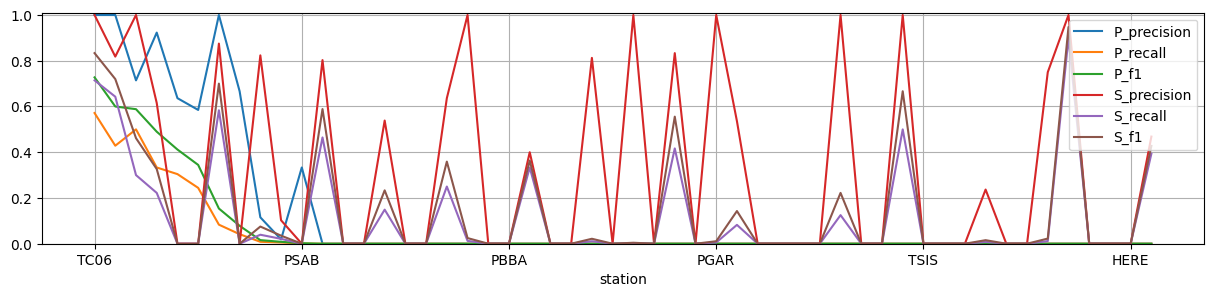

In [117]:
mp = metrics_path / "251201_many_raw_0.01"

many_list = []
for path in mp.glob("*.csv"):
    df = pd.read_csv(path).loc[[1]]
    df.columns = ["station"] + df.columns.tolist()[1:]
    df["name"] = path.parent.stem[7:]
    df.set_index("station", inplace=True)
    many_list.append(df)

df_metrics_many_raw = pd.concat(many_list).sort_values("P_f1", ascending=False)
df_metrics_many_raw.plot(ylim=(0, 1.01), figsize=(15,3), grid=True)
df_metrics_many_raw

,P_precision,P_recall,P_f1,S_precision,S_recall,S_f1,name
station,,,,,,,
TARO,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,many_raw_0
TCHI,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,many_raw_0
TTEL,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,many_raw_0
MACI,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,many_raw_0
TNTE,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,many_raw_0
TCHA,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,many_raw_0
PTON,0.714286,0.500000,0.588235,1.000000,0.300000,0.461538,many_raw_0
PMLU,0.584980,0.244224,0.344587,0.000000,0.000000,0.000000,many_raw_0
TC03,0.000000,0.000000,0.000000,1.000000,0.125000,0.222222,many_raw_0


#### MANY fine

,P_precision,P_recall,P_f1,S_precision,S_recall,S_f1,name
station,,,,,,,
GE32,0.857143,1.000000,0.923077,0.800000,1.000000,0.888889,many_fine_0
HDES,0.909091,0.833333,0.869565,0.800000,0.833333,0.816327,many_fine_0
TC03,0.761905,1.000000,0.864865,0.666667,0.875000,0.756757,many_fine_0
TC06,0.764706,0.928571,0.838710,0.650000,0.928571,0.764706,many_fine_0
TC01,0.714286,1.000000,0.833333,0.500000,0.400000,0.444444,many_fine_0
TC14,0.714286,1.000000,0.833333,0.666667,0.800000,0.727273,many_fine_0
TC02,0.705882,1.000000,0.827586,0.545455,0.500000,0.521739,many_fine_0
HCAS,0.731707,0.833333,0.779221,0.783784,0.805556,0.794521,many_fine_0
GART,0.807692,0.750000,0.777778,0.884615,0.821429,0.851852,many_fine_0


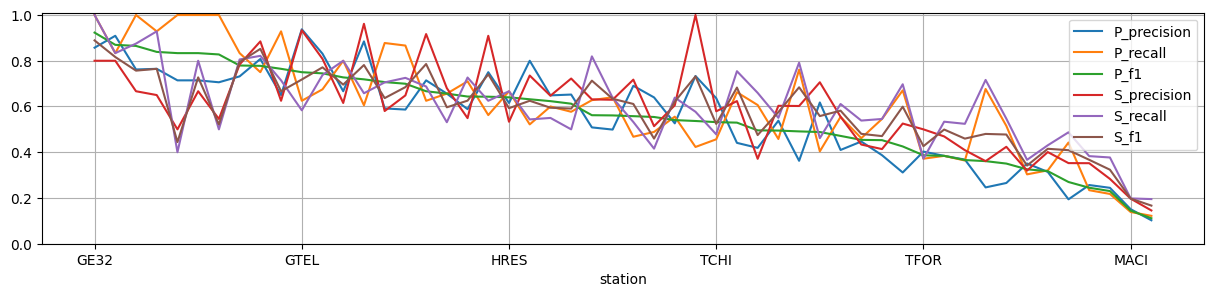

In [118]:
mp = metrics_path / "251202_many_fine_0.001"

many_list = []
for path in mp.glob("*.csv"):
    df = pd.read_csv(path).loc[[1]]
    df.columns = ["station"] + df.columns.tolist()[1:]
    df["name"] = path.parent.stem[7:]
    df.set_index("station", inplace=True)
    many_list.append(df)

df_metrics_many_fine = pd.concat(many_list).sort_values("P_f1", ascending=False)
df_metrics_many_fine.plot(ylim=(0, 1.01), figsize=(15,3), grid=True)
df_metrics_many_fine

In [84]:
df_metrics_many_fine.describe()

,P_precision,P_recall,P_f1,S_precision,S_recall,S_f1
count,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000
mean,0.557443,0.606071,0.565652,0.593969,0.606860,0.589185
std,0.212187,0.228031,0.198235,0.194546,0.173317,0.159996
min,0.102564,0.121951,0.111421,0.145455,0.195122,0.166667
25%,0.386359,0.457529,0.445961,0.460284,0.500000,0.476866
50%,0.603497,0.605823,0.559347,0.604170,0.597121,0.597864
75%,0.714286,0.752745,0.720881,0.708760,0.725560,0.714209
max,0.937500,1.000000,0.923077,1.000000,1.000000,0.888889


In [90]:
df_metrics_many_fine.drop("name", axis=1).median()

P_precision    0.603497
P_recall       0.605823
P_f1           0.559347
S_precision    0.604170
S_recall       0.597121
S_f1           0.597864
dtype: float64

<Axes: xlabel='station'>

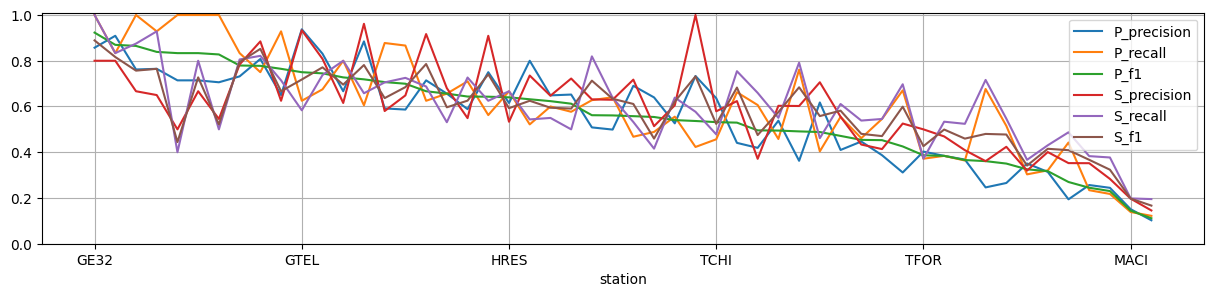

# MISCELLANEOUS